<a href="https://colab.research.google.com/github/aymuos/starship/blob/main/fundamental_EDA/fc_all_city_ICP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Feature Creator - All Cities (LaDe Dataset)

**Cities:** Shanghai, Hangzhou, Chongqing  
**Target:** `eta_mins = (sign_time - receipt_time) / 60`  
**Author:** Soumya - Thesis: Causal-informed RL for ETA Prediction

---

## Pipeline Overview

```
load_delivery()
    add_euclidean_distance()
    add_batch_features()
    add_workload()  [event-sweep O(n log n)]
    GPS: load_gps_window() -> courier_snapshot() -> filter_stale_gps()
    DuckDB: compute_speed_percentile() + compute_trajectory_features()
    merge delivery + state + trajectory
    add_temporal_features()
    add_workload_dual_representation()   <- THREE parallel encodings
    add_delivery_tiers()                 <- per-city ETA tiers
    add_icp_environment_labels()         <- city x tier = 9 ICP envs
    add_gps_missingness_flag()
    add_typecode_encoding()
    add_spatial_congestion()
    add_weather()
    final_sanity_check()
```

## Workload Representation Strategy

Chongqing has batch loads up to 68 (vs ~35 for Shanghai/Hangzhou).  
A single representation cannot serve both causal analysis and RL:

| Column | Method | Use |
|---|---|---|
| `workload_capped` | Hard clip at 20 (global) | **ICP / PCMCI+** |
| `workload_pct_rank` | Rank / n, city-relative | **RL state space** |
| `workload_log` | log10(x+1) | **LightGBM baseline** |

## Phase 1 - Invariant Causal Prediction (ICP)

**Environments:** `city x delivery_tier` -> 9 groups  
**Method:** Linear ICP via Levene + Kruskal-Wallis residual tests at alpha=0.05  
**Output:** `invariant_features.json` -> input to Phase 2 (PCMCI+)


## 0. Install & Imports

In [2]:
!pip install duckdb polars pyarrow --quiet

In [3]:
import polars as pl
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import date

pl.Config.set_tbl_rows(10)
print("Polars:", pl.__version__, " | DuckDB:", duckdb.__version__)


Polars: 1.35.2  | DuckDB: 1.3.2


## 1. Configuration

Edit the paths and parameters below before running.


In [4]:
# -- Paths --------------------------------------------------------------------
BASE         = "/content/drive/MyDrive/ml/PROCESSED/matched/city_divided/"
WEATHER_BASE = "/content/drive/MyDrive/ml/weather-outputs/"
OUTPUT_DIR   = "/content/drive/MyDrive/ml/PROCESSED/final/"
ICP_DIR      = "/content/drive/MyDrive/ml/PROCESSED/icp/"

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(ICP_DIR).mkdir(parents=True, exist_ok=True)

# -- Pipeline hyper-parameters ------------------------------------------------
PRE_MIN   = 15    # GPS look-back window (minutes)
MAX_GAP   = 30    # GPS staleness threshold (minutes)
GRID_SIZE = 500   # spatial grid cell size (affine units ~500 m)

# -- Workload representation parameters ---------------------------------------
GLOBAL_WORKLOAD_CAP = 20   # universal hard cap for ICP (all cities)
HIGH_LOAD_THRESH    = 10
OVERLOAD_THRESH     = 15

# -- ICP / causal parameters --------------------------------------------------
ICP_MIN_ENV_SAMPLES = 100   # min deliveries per environment for ICP
PCMCI_MIN_SAMPLES   = 200   # min per-courier observations for PCMCI+
ICP_ALPHA           = 0.05  # significance level for invariance tests

# -- ETA tier boundaries (per-city percentiles) -------------------------------
TIER_P_LOW  = 0.33   # smooth  -> [0,    P33]
TIER_P_MID  = 0.67   # normal  -> (P33,  P67]
TIER_P_HIGH = 0.95   # delayed -> (P67,  P95]  (above P95 stays 'delayed')

# -- City registry ------------------------------------------------------------
CITY_CONFIGS = [
    {
        "city_en"      : "Shanghai",
        "delivery_file": "shanghai_data.csv",
        "gps_file"     : "shanghai_delivery_data.parquet",
        "weather_file" : "shanghai_wsi_mar17_apr20_2021.csv",
        "holidays"     : ["2021-04-03", "2021-04-04", "2021-04-05"],
        "holiday_eve"  : "2021-04-02",
    },
    {
        "city_en"      : "Hangzhou",
        "delivery_file": "hangzhou_data.csv",
        "gps_file"     : "hangzhou_delivery_data.parquet",
        "weather_file" : "hangzhou_wsi_mar17_apr20_2021.csv",
        "holidays"     : ["2021-04-03", "2021-04-04", "2021-04-05"],
        "holiday_eve"  : "2021-04-02",
    },
    {
        "city_en"      : "Chongqing",
        "delivery_file": "chongqing_data.csv",
        "gps_file"     : "chongqing_delivery_data.parquet",
        "weather_file" : "chongqing_wsi_mar17_apr20_2021.csv",
        "holidays"     : ["2021-04-03", "2021-04-04", "2021-04-05"],
        "holiday_eve"  : "2021-04-02",
    },
]

# -- Feature sets -------------------------------------------------------------

# ICP / PCMCI+ -- uses globally-capped workload (same definition all cities)
ICP_FEATURES = [
    "order_id", "city", "delivery_tier", "environment",
    "workload_capped", "high_load", "overloaded",
    "batch_rank_capped", "late_batch", "extreme_batch", "batch_size",
    "speed_mean", "distance_travelled", "gps_points", "gps_gap_min",
    "is_trajectory_available", "pickup_destination_distance",
    "hour_sin", "hour_cos", "day_sin", "day_cos",
    "is_holiday", "is_holiday_eve", "is_weekend", "delivery_sequence",
    "spatial_congestion_norm", "courier_local_load",
    "WSI", "precipitation", "temperature_2m", "windspeed_10m",
    "typecode_grouped_type 1", "typecode_grouped_type 2",
    "typecode_grouped_type 3",
    "eta_mins",
]

# RL state space -- uses city-relative workload (no info loss for Chongqing)
RL_FEATURES = [
    "order_id", "city", "delivery_tier", "environment",
    "workload_pct_rank", "workload_log", "workload_tier",
    "batch_rank_capped", "late_batch", "batch_size",
    "speed_mean", "distance_travelled", "gps_points",
    "is_trajectory_available", "pickup_destination_distance",
    "hour_sin", "hour_cos", "day_sin", "day_cos",
    "is_holiday", "is_weekend", "delivery_sequence",
    "spatial_congestion_norm", "courier_local_load",
    "WSI", "precipitation", "typecode_cb",
    "eta_mins",
]

SELECTED_FEATURES = sorted(set(ICP_FEATURES + RL_FEATURES))


## 2. Pipeline Functions

All transformation logic lives here. Functions are stateless — they receive a
dataframe (and sometimes a DuckDB connection / path) and return a new dataframe.


### 2.1 `load_delivery` — Load and normalise the delivery CSV

In [5]:
def load_delivery(csv_path: str) -> pl.DataFrame:
    """
    Load the city delivery CSV, parse datetimes, drop redundant columns,
    rename the target variable, and sort for downstream ASOF joins.

    Returns
    -------
    pl.DataFrame  sorted by (delivery_user_id, receipt_time)
    """
    df = (
        pl.read_csv(csv_path)
        .with_columns([
            pl.col("receipt_time").str.to_datetime("%Y-%m-%d %H:%M:%S"),
            pl.col("sign_time").str.to_datetime("%Y-%m-%d %H:%M:%S"),
        ])
        .drop(["sign_lat", "sign_lng"])          # redundant destination cols
        .rename({"horizon_ETA": "eta_mins"})     # canonical target name
        .with_columns(pl.col("delivery_user_id").cast(pl.Utf8))
        .sort(["delivery_user_id", "receipt_time"])
    )
    print(f"  Loaded {df.height:,} deliveries | {df['delivery_user_id'].n_unique()} couriers")
    return df


### 2.2 `load_gps_window` — Fetch relevant GPS records via DuckDB

In [6]:
def load_gps_window(
    con: duckdb.DuckDBPyConnection,
    gps_path: str,
    couriers: list,
    start_time,
    end_time,
    pre_min: int = PRE_MIN,
) -> pl.DataFrame:
    """
    Pull GPS rows for the relevant couriers and time range from parquet.
    Uses DuckDB for push-down filtering — avoids loading the full GPS file.

    Returns
    -------
    pl.DataFrame  columns: delivery_user_id, gps_time, lat, lng
                  sorted by (delivery_user_id, gps_time)
    """
    # DuckDB requires a tuple with ≥2 elements for the IN clause
    couriers_tuple = tuple(couriers) if len(couriers) > 1 else (couriers[0], couriers[0])

    gps_df = con.execute(f"""
        SELECT postman_id, gps_time, lat, lng
        FROM parquet_scan('{gps_path}')
        WHERE postman_id IN {couriers_tuple}
          AND gps_time BETWEEN
              TIMESTAMP '{start_time}' - INTERVAL '{pre_min} minutes'
              AND TIMESTAMP '{end_time}'
    """).pl()

    gps_df = (
        gps_df
        .rename({"postman_id": "delivery_user_id"})
        .sort(["delivery_user_id", "gps_time"])
    )
    print(f"  GPS rows loaded: {gps_df.height:,}")
    return gps_df


### 2.3 `courier_snapshot` + `filter_stale_gps` — Last known position

In [7]:
def courier_snapshot(delivery: pl.DataFrame, gps_df: pl.DataFrame) -> pl.DataFrame:
    """
    ASOF backward join: for each receipt_time, attach the courier's most recent
    GPS point at or before that moment.

    Returns
    -------
    pl.DataFrame  delivery + last_x, last_y, last_gps_time, gps_gap_min
    """
    state = delivery.join_asof(
        gps_df,
        left_on="receipt_time",
        right_on="gps_time",
        by="delivery_user_id",
        strategy="backward",
    ).rename({"lat": "last_x", "lng": "last_y", "gps_time": "last_gps_time"})

    state = state.with_columns(
        (pl.col("receipt_time") - pl.col("last_gps_time"))
        .dt.total_minutes()
        .alias("gps_gap_min")
    )
    return state


def filter_stale_gps(state: pl.DataFrame, max_gap: int = MAX_GAP) -> pl.DataFrame:
    """
    Invalidate GPS matches older than max_gap minutes.
    Sets gps_gap_min, last_x, last_y to null for stale matches.

    Rationale: GPS older than 30 min is operationally unreliable; treating it
    as missing is safer than propagating stale location estimates.

    Returns
    -------
    pl.DataFrame  state with stale GPS columns nulled out
    """
    state = state.with_columns(
        pl.when(pl.col("gps_gap_min") <= max_gap)
          .then(pl.col("gps_gap_min"))
          .otherwise(None)
          .alias("gps_gap_min")
    )
    state = state.with_columns([
        pl.when(pl.col("gps_gap_min").is_null()).then(None).otherwise(pl.col("last_x")).alias("last_x"),
        pl.when(pl.col("gps_gap_min").is_null()).then(None).otherwise(pl.col("last_y")).alias("last_y"),
    ])

    total   = state.height
    missing = state["gps_gap_min"].null_count()
    print(f"  GPS coverage after {max_gap}-min filter: "
          f"{total - missing:,}/{total:,} ({(total-missing)/total*100:.1f}%)")
    return state


### 2.4 `compute_speed_percentile` — 99th-percentile speed cap

In [8]:
def compute_speed_percentile(
    con: duckdb.DuckDBPyConnection,
    gps_path: str,
    percentile: float = 0.99,
) -> float:
    """
    Compute a robust speed cap from the full GPS parquet.

    Filters:
      dt > 5 s    — removes GPS duplicates (sampling ≈ 20 s)
      dt < 600 s  — removes long gaps that create phantom distance
      dist < 10000 — removes privacy-related coordinate jumps

    Returns
    -------
    float  speed threshold in affine coordinate units / second
    """
    speed_q = con.execute(f"""
        WITH motion AS (
            SELECT
                SQRT(POWER(lat - LAG(lat) OVER w, 2) +
                     POWER(lng - LAG(lng) OVER w, 2)) AS dist,
                EXTRACT(EPOCH FROM (gps_time - LAG(gps_time) OVER w)) AS dt
            FROM parquet_scan('{gps_path}')
            WINDOW w AS (PARTITION BY postman_id ORDER BY gps_time)
        ),
        clean AS (
            SELECT dist / dt AS speed
            FROM motion
            WHERE dt > 5 AND dt < 600 AND dist < 10000
        )
        SELECT quantile_cont(speed, {percentile}) FROM clean
    """).fetchone()[0]

    print(f"  Speed {percentile*100:.0f}th percentile cap: {speed_q:.4f} units/s")
    return speed_q


### 2.5 `compute_trajectory_features` — 15-min pre-delivery GPS window

In [9]:
def compute_trajectory_features(
    con: duckdb.DuckDBPyConnection,
    gps_path: str,
    speed_cap: float,
    pre_min: int = PRE_MIN,
) -> pl.DataFrame:
    """
    For each order, aggregate GPS segments in [receipt_time - pre_min, receipt_time].

    Speed filtering (applied to each segment):
      dt ≤ 1 s     — GPS duplicate / noise
      dist > 5000  — privacy jump (affine coordinate teleportation)
      dist/dt > speed_cap — physically impossible speed (99th-pct threshold)

    Returns
    -------
    pl.DataFrame  columns: order_id, gps_points, speed_mean, distance_travelled
    """
    traj = con.execute(f"""
        WITH gps_window AS (
            SELECT
                d.order_id,
                g.gps_time, g.lat, g.lng,
                LAG(g.lat)      OVER (PARTITION BY d.order_id ORDER BY g.gps_time) AS prev_lat,
                LAG(g.lng)      OVER (PARTITION BY d.order_id ORDER BY g.gps_time) AS prev_lng,
                LAG(g.gps_time) OVER (PARTITION BY d.order_id ORDER BY g.gps_time) AS prev_time
            FROM delivery_tbl d
            JOIN parquet_scan('{gps_path}') g
              ON g.postman_id = d.delivery_user_id
            WHERE g.gps_time BETWEEN
                d.receipt_time - INTERVAL '{pre_min} minutes'
                AND d.receipt_time
        ),
        motion AS (
            SELECT
                order_id,
                SQRT(POWER(lat - prev_lat, 2) + POWER(lng - prev_lng, 2)) AS dist,
                EXTRACT(EPOCH FROM (gps_time - prev_time)) AS dt
            FROM gps_window
        ),
        speed_calc AS (
            SELECT
                order_id, dist, dt,
                CASE
                    WHEN dt IS NULL       THEN NULL   -- first row in window
                    WHEN dt <= 1          THEN NULL   -- GPS duplicate / noise
                    WHEN dist > 5000      THEN NULL   -- privacy coord jump
                    WHEN dist / dt > {speed_cap} THEN NULL  -- speed cap
                    ELSE dist / dt
                END AS speed
            FROM motion
        )
        SELECT
            order_id,
            COUNT(*)        AS gps_points,
            AVG(speed)      AS speed_mean,
            SUM(dist)       AS distance_travelled
        FROM speed_calc
        GROUP BY order_id
    """).pl()

    print(f"  Trajectory features computed for {traj.height:,} orders")
    return traj


### 2.6 `add_euclidean_distance` — Pickup → destination distance

In [10]:
def add_euclidean_distance(delivery: pl.DataFrame) -> pl.DataFrame:
    """
    Euclidean distance between pickup (receipt) and destination (POI)
    in the affine coordinate space (≈ metres at ~1e6 scale).

    Adds column: pickup_destination_distance
    """
    return delivery.with_columns(
        ((pl.col("receipt_lng") - pl.col("poi_lng")).pow(2) +
         (pl.col("receipt_lat") - pl.col("poi_lat")).pow(2)).sqrt()
        .alias("pickup_destination_distance")
    )


### 2.7 `add_batch_features` — Batch size and intra-batch rank

In [11]:
def add_batch_features(delivery: pl.DataFrame) -> pl.DataFrame:
    """
    Compute batch_size and batch_rank for simultaneous dispatcher pushes.

    Batch = set of orders sharing the same (delivery_user_id, receipt_time).
    order_id is the tiebreaker when multiple orders arrive at the exact same
    timestamp — this is critical for deterministic, reproducible ranks.

    Adds columns: batch_size, batch_rank
    """
    delivery = delivery.sort(["delivery_user_id", "receipt_time", "order_id"])

    delivery = delivery.with_columns(
        pl.len().over(["delivery_user_id", "receipt_time"]).alias("batch_size")
    )
    delivery = delivery.with_columns(
        pl.int_range(0, pl.len())
          .over(["delivery_user_id", "receipt_time"])
          .alias("batch_rank")
    )
    n_batched = delivery.filter(pl.col("batch_size") > 1).height
    print(f"  Orders in multi-order batches: {n_batched:,} "
          f"| max batch_size: {delivery['batch_size'].max()}")
    return delivery


### 2.8 `add_workload` — Concurrent active orders (event-sweep)

In [12]:
def add_workload(delivery: pl.DataFrame) -> pl.DataFrame:
    """
    Compute active_orders_at_receipt_time via a linear-time event-sweep
    algorithm (O(n log n) sort + O(n) scan).

    Why not self-join?  A self-join is O(n²) — prohibitive at 40k+ orders.

    Algorithm:
        start_events (+1, priority=1) at receipt_time
        end_events   (-1, priority=0) at sign_time   [resolve before receipts]
        cumsum(delta) over (courier, time, priority) → active_orders
        ASOF join back to delivery on receipt_time → subtract self-count

    Adds column: active_orders_at_receipt_time
    """
    delivery = delivery.sort(["delivery_user_id", "receipt_time"])

    start_events = delivery.select([
        "delivery_user_id",
        pl.col("receipt_time").alias("time"),
        pl.lit(1).alias("delta"),
        pl.lit(1).alias("priority"),   # receipts resolve after sign events
    ])
    end_events = delivery.select([
        "delivery_user_id",
        pl.col("sign_time").alias("time"),
        pl.lit(-1).alias("delta"),
        pl.lit(0).alias("priority"),   # sign events resolve first
    ])

    events = (
        pl.concat([start_events, end_events])
        .sort(["delivery_user_id", "time", "priority"])
        .with_columns(
            pl.col("delta").cum_sum().over("delivery_user_id").alias("active_orders")
        )
    )

    # ASOF: for each receipt_time, grab the cumulative count just before/at it
    workload = delivery.join_asof(
        events.select(["delivery_user_id", "time", "active_orders"]),
        left_on="receipt_time",
        right_on="time",
        by="delivery_user_id",
        strategy="backward",
    )

    # Subtract self — the current order is included in the sweep count
    workload = workload.with_columns(
        (pl.col("active_orders") - 1).clip(lower_bound=0)
        .alias("active_orders_at_receipt_time")
    )

    print(f"  Workload | mean: {workload['active_orders_at_receipt_time'].mean():.2f} "
          f"| max: {workload['active_orders_at_receipt_time'].max()}")
    return workload


### 2.9 `add_temporal_features` — Cyclical time + calendar flags

In [13]:
def add_temporal_features(
    features: pl.DataFrame,
    holidays: list,
    holiday_eve: str,
) -> pl.DataFrame:
    """
    Adds time-of-day and calendar context features.

    Cyclical encoding preserves the circular topology of time:
        sin/cos(2π × hour / 24) — avoids the 23→0 discontinuity.

    Adds columns:
        hour, weekday, day_of_week
        hour_sin, hour_cos, day_sin, day_cos
        is_weekend, is_holiday, is_holiday_eve
        delivery_sequence  (cumulative per courier — fatigue proxy)
    """
    features = features.with_columns([
        pl.col("receipt_time").dt.hour().alias("hour"),
        pl.col("receipt_time").dt.weekday().alias("weekday"),
        pl.col("receipt_time").dt.weekday().alias("day_of_week"),
    ])

    features = features.with_columns([
        (2 * np.pi * pl.col("hour")    / 24).sin().alias("hour_sin"),
        (2 * np.pi * pl.col("hour")    / 24).cos().alias("hour_cos"),
        (2 * np.pi * pl.col("weekday") / 7 ).sin().alias("day_sin"),
        (2 * np.pi * pl.col("weekday") / 7 ).cos().alias("day_cos"),
    ])

    features = features.with_columns([
        # Polars weekday: Mon=1 … Sun=7
        (pl.col("weekday") >= 6).cast(pl.Int8).alias("is_weekend"),
        pl.col("receipt_time").dt.date().cast(pl.Utf8)
          .is_in(holidays).cast(pl.Int8).alias("is_holiday"),
        (pl.col("receipt_time").dt.date().cast(pl.Utf8) == holiday_eve)
          .cast(pl.Int8).alias("is_holiday_eve"),
    ])

    features = features.with_columns(
        pl.col("order_id").cum_count().over("delivery_user_id")
          .alias("delivery_sequence")
    )
    return features


### 2.10 `add_workload_dual_representation` — Three parallel workload encodings

Produces three representations from `active_orders_at_receipt_time`:

**Rep 1 — Global consistent** (`workload_capped`, cap=20) for ICP/PCMCI+.  
Same definition in all cities so invariance tests are valid.  
M/G/1 saturation inflection is at ~15 orders in all three cities.

**Rep 2 — City-relative** (`workload_pct_rank`, `workload_tier`) for RL.  
P80 in Chongqing = same relative stress as P80 in Shanghai.  
No information above cap=20 is discarded.

**Rep 3 — Log-compressed** (`workload_log`) for LightGBM/neural baselines.  
log10(x+1) compresses the Chongqing tail (20->68) without arbitrary cutoff.

In [14]:
def add_workload_dual_representation(
    features: pl.DataFrame,
    city_en: str,
    global_cap: int           = GLOBAL_WORKLOAD_CAP,
    high_load_thresh: int     = HIGH_LOAD_THRESH,
    overload_thresh: int      = OVERLOAD_THRESH,
    rank_cap: int             = 15,
    late_batch_thresh: int    = 8,
    extreme_batch_thresh: int = 12,
) -> pl.DataFrame:
    """
    Three parallel workload representations for different modelling goals.

    Rep 1 - Global consistent (for ICP / PCMCI+)
        workload_capped   : clip at global_cap (same meaning in ALL cities)
        high_load         : binary > high_load_thresh
        overloaded        : binary > overload_thresh

        Rationale: ICP tests coefficient invariance across environments.
        If the feature definition changes per city the test is invalid.
        The M/G/1 saturation inflection is at ~15 orders in all three cities,
        so cap=20 preserves the operationally meaningful signal.

    Rep 2 - City-relative (for RL state space)
        workload_pct_rank : rank / n in [0,1] (continuous percentile position)
        workload_tier     : ordinal 0-3 based on within-city P50/P75/P90

        Rationale: Chongqing workload=40 is the same relative stress as
        Shanghai workload=18. The RL policy transfers across cities without
        scale mismatch, and NO information above cap=20 is discarded.

    Rep 3 - Log-compressed (for LightGBM / neural baselines)
        workload_log : log10(active_orders + 1)

        Rationale: Tree splits on raw counts waste depth on the long tail
        (20 -> 68 in Chongqing). Log compression makes each unit increase
        equally informative across the full range.

    Batch non-linear indicators (shared across all representations):
        batch_rank_capped, late_batch, extreme_batch
    """
    raw = pl.col("active_orders_at_receipt_time")

    # Rep 1: Global hard cap
    features = features.with_columns([
        raw.clip(upper_bound=global_cap).alias("workload_capped"),
        (raw > high_load_thresh).cast(pl.Int8).alias("high_load"),
        (raw > overload_thresh).cast(pl.Int8).alias("overloaded"),
    ])

    # Rep 2: City-relative percentile
    p50 = features["active_orders_at_receipt_time"].quantile(0.50)
    p75 = features["active_orders_at_receipt_time"].quantile(0.75)
    p90 = features["active_orders_at_receipt_time"].quantile(0.90)
    p95 = features["active_orders_at_receipt_time"].quantile(0.95)
    p99 = features["active_orders_at_receipt_time"].quantile(0.99)

    features = features.with_columns([
        (raw.rank() / raw.len()).alias("workload_pct_rank"),
        pl.when(raw <= p50).then(pl.lit(0))
          .when(raw <= p75).then(pl.lit(1))
          .when(raw <= p90).then(pl.lit(2))
          .otherwise(pl.lit(3))
          .cast(pl.Int8).alias("workload_tier"),
    ])

    # Rep 3: Log-compressed
    features = features.with_columns(
        (raw + 1).log(base=10).alias("workload_log")
    )

    # Batch non-linear indicators
    features = features.with_columns([
        pl.col("batch_rank").clip(upper_bound=rank_cap).alias("batch_rank_capped"),
        (pl.col("batch_rank") > late_batch_thresh).cast(pl.Int8).alias("late_batch"),
        (pl.col("batch_rank") > extreme_batch_thresh).cast(pl.Int8).alias("extreme_batch"),
    ])

    # Diagnostics
    wmax    = features["active_orders_at_receipt_time"].max()
    n_above = features.filter(raw > global_cap).height
    n_total = features.height
    print(f"  {city_en} workload | P50={p50:.0f} P75={p75:.0f} P90={p90:.0f} "
          f"P95={p95:.0f} P99={p99:.0f} max={wmax:.0f}")
    print(f"    Above global cap ({global_cap}): "
          f"{n_above:,}/{n_total:,} ({n_above/n_total*100:.1f}%)")
    print(f"    workload_pct_rank range: "
          f"[{features['workload_pct_rank'].min():.3f}, "
          f"{features['workload_pct_rank'].max():.3f}]")
    return features


### 2.11 `add_delivery_tiers` — Per-city ETA tier segmentation

Cuts `eta_mins` at within-city P33/P67 into `smooth / normal / delayed`.
These tiers are the second dimension of the ICP environment label.
Values above P95 stay in 'delayed' to avoid tiny environment sample sizes.

In [15]:
def add_delivery_tiers(features: pl.DataFrame, city_en: str) -> pl.DataFrame:
    """
    Segment deliveries into per-city ETA tiers using within-city percentiles.

    Boundaries are computed on the FULL eta_mins range.
    Values above P95 stay in 'delayed' -- extreme outliers do not get a
    separate tier to avoid tiny environment sample sizes in ICP.

    Adds columns:
        eta_p33, eta_p67, eta_p95  -- city thresholds stored per row
        delivery_tier              -- 'smooth' | 'normal' | 'delayed'
    """
    p33 = float(features["eta_mins"].quantile(TIER_P_LOW))
    p67 = float(features["eta_mins"].quantile(TIER_P_MID))
    p95 = float(features["eta_mins"].quantile(TIER_P_HIGH))

    features = features.with_columns([
        pl.lit(p33).alias("eta_p33"),
        pl.lit(p67).alias("eta_p67"),
        pl.lit(p95).alias("eta_p95"),
        pl.when(pl.col("eta_mins") <= p33).then(pl.lit("smooth"))
          .when(pl.col("eta_mins") <= p67).then(pl.lit("normal"))
          .otherwise(pl.lit("delayed"))
          .alias("delivery_tier"),
    ])

    counts = features.group_by("delivery_tier").len().sort("delivery_tier").to_dicts()
    print(f"  {city_en} ETA tiers | P33={p33:.1f}  P67={p67:.1f}  P95={p95:.1f} mins")
    print(f"    Tier counts: {counts}")
    return features


### 2.12 `add_icp_environment_labels` — ICP environment identifiers

Creates `environment = city + '_' + delivery_tier`  
(e.g. `Shanghai_smooth`, `Chongqing_delayed`).  
Up to 9 environments across 3 cities x 3 tiers.  
`environment_id` is an integer encoding for statsmodels/sklearn.

In [16]:
def add_icp_environment_labels(features: pl.DataFrame) -> pl.DataFrame:
    """
    Compose the ICP environment label from city + delivery_tier.

    environment = city x tier  ->  up to 9 environments across 3 cities x 3 tiers.
    e.g. 'Shanghai_smooth', 'Chongqing_delayed'

    Adds columns:
        environment     -- string label
        environment_id  -- integer encoding (sorted alphabetically, for sklearn)
    """
    features = features.with_columns(
        (pl.col("city") + pl.lit("_") + pl.col("delivery_tier"))
        .alias("environment")
    )
    envs    = sorted(features["environment"].unique().to_list())
    env_map = {e: i for i, e in enumerate(envs)}

    features = features.with_columns(
        pl.col("environment")
          .map_elements(lambda x: env_map[x], return_dtype=pl.Int32)
          .alias("environment_id")
    )

    print(f"  ICP environments ({len(envs)}):")
    for e in envs:
        n    = features.filter(pl.col("environment") == e).height
        flag = "OK" if n >= ICP_MIN_ENV_SAMPLES else "WARN: BELOW THRESHOLD"
        print(f"    {e:<32} {n:>6,} deliveries  {flag}")
    return features


### 2.13 `add_gps_missingness_flag` — Structural fill + indicator

In [17]:
def add_gps_missingness_flag(features: pl.DataFrame) -> pl.DataFrame:
    """
    Encode GPS absence as a first-class operational state.

    Strategy: structural fill (0) + binary indicator, NOT statistical imputation.
    Rationale: missing GPS ≠ stationary courier. It correlates with indoor
    deliveries, dense urban canyons, and device quality — structurally different
    from observed zero-speed movement.

    Diagnostic: ρ(workload, is_trajectory_available) ≈ 0.03 (HZ) / -0.07 (SH)
    — near-zero confirms the two signals are independent.

    Adds columns:
        is_trajectory_available  (0/1)
        fills speed_mean, distance_travelled, gps_points with 0 where null
    """
    features = features.with_columns(
        pl.col("speed_mean").is_not_null().cast(pl.Int8).alias("is_trajectory_available")
    )
    features = features.with_columns([
        pl.col("speed_mean").fill_null(0),
        pl.col("distance_travelled").fill_null(0),
        pl.col("gps_points").fill_null(0),
    ])

    corr = features.select(
        pl.corr("active_orders_at_receipt_time", "is_trajectory_available").alias("rho")
    ).item()
    print(f"  ρ(workload, GPS available) = {corr:.4f}  "
          f"[near-zero ✓ → independent signals]")
    return features


### 2.14 `add_typecode_encoding` — OHE grouping + frequency encoding

In [18]:
def add_typecode_encoding(features: pl.DataFrame, top_n: int = 3) -> pl.DataFrame:
    """
    Dual encoding for the package type field.

    (a) OHE grouping — top_n codes → named groups; rest → 'rare'.
        One-hot encoded → binary columns for causal graph root nodes.
    (b) Frequency encoding — each code replaced by its count in the dataset.
        Dense ordinal signal for tree models and bandit policies.

    Adds columns:
        typecode_grouped          (categorical: 'type 1', 'type 2', 'type 3', 'rare')
        typecode_grouped_type 1   (binary OHE)
        typecode_grouped_type 2   (binary OHE)
        typecode_grouped_type 3   (binary OHE)
        typecode_cb               (frequency encoding)
    """
    # (a) Group
    top_codes = (
        features.select(pl.col("typecode").value_counts(sort=True))
        .unnest("typecode")
        .head(top_n)
        .get_column("typecode")
        .to_list()
    )
    mapping = {code: f"type {i+1}" for i, code in enumerate(top_codes)}

    features = features.with_columns(
        pl.col("typecode")
          .map_elements(lambda x: mapping.get(x, "rare"), return_dtype=pl.Utf8)
          .alias("typecode_grouped")
    )

    # OHE for top_n groups (exclude 'rare' as baseline)
    for i in range(1, top_n + 1):
        label = f"type {i}"
        features = features.with_columns(
            (pl.col("typecode_grouped") == label).cast(pl.Int8).alias(f"typecode_grouped_{label}")
        )

    # (b) Frequency encode
    freq = (
        features.group_by("typecode").len().rename({"len": "typecode_cb"})
    )
    features = features.join(freq, on="typecode", how="left")
    features = features.with_columns(pl.col("typecode_cb").fill_null(0))

    print(f"  typecode groups: {features['typecode_grouped'].value_counts().sort('typecode_grouped')}")
    return features


### 2.15 `add_spatial_congestion` — Grid-based SCI + courier local load

In [19]:
def add_spatial_congestion(
    features: pl.DataFrame,
    grid_size: int = GRID_SIZE,
) -> pl.DataFrame:
    """
    Spatial Congestion Index (SCI) — adapted from Ke et al. (SIGKDD 2017).

    SCI(g, t) = number of deliveries in grid cell g during hour t.
    Tessellates the affine coordinate space into grid_size-unit cells.

    courier_local_load = delivery count per (courier, hour) — finer congestion.
    spatial_congestion_norm = z-score of SCI (makes it model-ready).

    Adds columns:
        grid_x, grid_y                — cell coordinates
        time_window                   — receipt_time truncated to hour
        spatial_congestion_index      — raw count
        spatial_congestion_norm       — z-score
        courier_local_load            — per-courier hourly count
    """
    features = features.with_columns([
        (pl.col("receipt_lng") // grid_size).alias("grid_x"),
        (pl.col("receipt_lat") // grid_size).alias("grid_y"),
        pl.col("receipt_time").dt.truncate("1h").alias("time_window"),
    ])

    sci = (
        features.group_by(["grid_x", "grid_y", "time_window"])
        .len().rename({"len": "spatial_congestion_index"})
    )
    features = features.join(sci, on=["grid_x", "grid_y", "time_window"], how="left")

    cll = (
        features.group_by(["delivery_user_id", "time_window"])
        .len().rename({"len": "courier_local_load"})
    )
    features = features.join(cll, on=["delivery_user_id", "time_window"], how="left")

    sci_mean = features["spatial_congestion_index"].mean()
    sci_std  = features["spatial_congestion_index"].std()
    features = features.with_columns(
        ((pl.col("spatial_congestion_index") - sci_mean) / sci_std)
        .alias("spatial_congestion_norm")
    )
    print(f"  SCI | mean: {sci_mean:.2f} | std: {sci_std:.2f} "
          f"| max: {features['spatial_congestion_index'].max()}")
    return features


### 2.16 `add_weather` — Temporal ASOF join with hourly weather

In [ ]:
def add_weather(
    features: pl.DataFrame,
    weather_csv: str,
    city_en: str,
) -> pl.DataFrame:
    """
    Join hourly weather observations to deliveries via ASOF backward join.
    Matches each receipt_time to the most recent prior weather record.

    Fix vs original: drop 'city' from the weather DF *before* joining, so
    the 'city' column already present on features is not overwritten or
    duplicated (the original .drop('city') after join was dropping the
    feature city column, not the weather one).

    Adds columns: temperature_2m, precipitation, windspeed_10m, WSI,
                  norm_weathercode_sev
    """
    weather = (
        pl.read_csv(weather_csv)
        .with_columns(
            pl.col("datetime").str.strptime(pl.Datetime, strict=False)
            .alias("weather_time")
        )
        .drop("datetime")
        .filter(pl.col("city") == city_en)
        .drop("city")           # drop BEFORE join so features.city is preserved
        .sort("weather_time")
    )

    features = features.sort("receipt_time")
    features = features.join_asof(
        weather,
        left_on="receipt_time",
        right_on="weather_time",
        strategy="backward",
    )

    pct_null = features["WSI"].null_count() / features.height * 100
    print(f"  Weather joined | WSI null: {pct_null:.1f}%")
    return features


### 2.17 `final_sanity_check` — Validation gates

In [21]:
def final_sanity_check(features: pl.DataFrame, city_en: str) -> None:
    """
    Six-gate validation. Raises AssertionError on failure so the pipeline
    stops rather than silently saving a corrupt features file.
    """
    print(f"\n{'-'*60}")
    print(f"  Sanity check: {city_en}")
    print(f"{'-'*60}")

    # 1. No null targets
    null_eta = features["eta_mins"].null_count()
    assert null_eta == 0, f"FAIL: {null_eta} null eta_mins!"
    print(f"  OK  eta_mins nulls: 0")

    # 2. Row uniqueness
    assert features.height == features["order_id"].n_unique(), \
        "FAIL: duplicate order_id rows!"
    print(f"  OK  Rows == unique order_ids: {features.height:,}")

    # 3. No accidental join duplicates
    dup_cols = [c for c in features.columns if c.endswith("_right")]
    assert not dup_cols, f"FAIL: duplicate columns found: {dup_cols}"
    print(f"  OK  No duplicate columns")

    # 4. Tier completeness
    if "delivery_tier" in features.columns:
        null_tier = features["delivery_tier"].null_count()
        assert null_tier == 0, f"FAIL: {null_tier} null delivery_tier!"
        print(f"  OK  delivery_tier nulls: 0")

    # 5. ICP environment sample sizes
    if "environment" in features.columns:
        low = (features.group_by("environment").len()
               .filter(pl.col("len") < ICP_MIN_ENV_SAMPLES))
        if low.height > 0:
            print(f"  WARN  Environments below {ICP_MIN_ENV_SAMPLES} samples:")
            print(low)
        else:
            print(f"  OK  All environments >= {ICP_MIN_ENV_SAMPLES} samples")

    # 6. Key feature null counts
    key_cols = [
        "active_orders_at_receipt_time", "workload_capped",
        "workload_pct_rank", "workload_log", "batch_rank", "hour_sin", "WSI",
    ]
    for col in key_cols:
        if col in features.columns:
            n = features[col].null_count()
            flag = "OK" if n == 0 else "WARN"
            print(f"  {flag}  {col} nulls: {n}")

    print(f"  Columns : {len(features.columns)}  |  Rows : {features.height:,}")
    print(f"{'-'*60}\n")


## 3. EDA / Diagnostic Functions

Quick visual diagnostics per city. Call these after `build_city_features()`
or from the cross-city comparison section.


In [22]:
def plot_speed_ccdf(con, gps_path: str, city_en: str) -> None:
    """
    Log-log CCDF of courier speed.
    A heavy right tail confirms the trajectory captures real inter-zone movement.
    A sharp drop-off at the far end = rare cross-city reallocation events.
    """
    speed_df = con.execute(f"""
        WITH motion AS (
            SELECT
                SQRT(POWER(lat - LAG(lat) OVER w, 2) +
                     POWER(lng - LAG(lng) OVER w, 2)) AS dist,
                EXTRACT(EPOCH FROM (gps_time - LAG(gps_time) OVER w)) AS dt
            FROM parquet_scan('{gps_path}')
            WINDOW w AS (PARTITION BY postman_id ORDER BY gps_time)
        )
        SELECT dist / dt AS speed
        FROM motion
        WHERE dt > 0 AND dist IS NOT NULL AND dist / dt IS NOT NULL
    """).pl().sort("speed")

    n = speed_df.height
    ccdf = speed_df.with_row_index("rank").with_columns(
        (1 - pl.col("rank") / n).alias("ccdf")
    )
    s = ccdf["speed"].to_numpy()
    p = ccdf["ccdf"].to_numpy()
    mask = (s > 0) & (p > 0)

    plt.figure(figsize=(6, 4))
    plt.loglog(s[mask], p[mask])
    plt.xlabel("Speed (log scale)")
    plt.ylabel("P(Speed ≥ v) (log scale)")
    plt.title(f"Courier Speed CCDF — {city_en}")
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_workload_saturation(features: pl.DataFrame, city_en: str) -> None:
    """
    Bar chart: mean ETA vs active orders (clipped at 20).
    Illustrates M/G/1 saturation curve — delay explodes near ρ→1.
    """
    plot_df = (
        features
        .with_columns(pl.col("active_orders_at_receipt_time").clip(upper_bound=20))
        .group_by("active_orders_at_receipt_time")
        .agg(pl.mean("eta_mins").alias("mean_eta"), pl.len().alias("n"))
        .sort("active_orders_at_receipt_time")
        .to_pandas()
    )
    plt.figure(figsize=(11, 4))
    sns.barplot(x="active_orders_at_receipt_time", y="mean_eta",
                data=plot_df, palette="viridis",
                hue="active_orders_at_receipt_time", legend=False)
    plt.axvline(x=14.5, color="red", linestyle="--", alpha=0.7, label="Saturation threshold")
    plt.title(f"Workload Saturation Curve — {city_en}")
    plt.xlabel("Active Orders at Receipt Time (clipped at 20)")
    plt.ylabel("Mean ETA (mins)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_batch_rank_eta(features: pl.DataFrame, city_en: str) -> None:
    """
    Line chart: mean ETA vs batch rank (clipped at 15).
    Monotonic rise validates the late_batch binary feature.
    """
    plot_df = (
        features
        .with_columns(pl.col("batch_rank").clip(upper_bound=15))
        .group_by("batch_rank")
        .agg(pl.mean("eta_mins").alias("mean_eta"), pl.len().alias("n"))
        .sort("batch_rank")
        .to_pandas()
    )
    plt.figure(figsize=(9, 4))
    plt.plot(plot_df["batch_rank"], plot_df["mean_eta"], marker="o")
    plt.fill_between(plot_df["batch_rank"],
                     plot_df["mean_eta"] * 0.9, plot_df["mean_eta"] * 1.1,
                     alpha=0.15)
    plt.axvline(x=8, color="orange", linestyle="--", alpha=0.7, label="late_batch threshold")
    plt.title(f"Batch Rank vs Mean ETA — {city_en}")
    plt.xlabel("Batch Rank (clipped at 15)")
    plt.ylabel("Mean ETA (mins)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_eta_distribution(features: pl.DataFrame, city_en: str, clip_pct: float = 0.95) -> None:
    """
    KDE of eta_mins clipped at the 95th percentile to suppress extreme outliers.
    """
    cap = features["eta_mins"].quantile(clip_pct)
    data = features.filter(pl.col("eta_mins") <= cap)["eta_mins"].to_numpy()
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data, fill=True)
    plt.axvline(data.mean(), color="red",  linestyle="--", label=f"Mean {data.mean():.0f}")
    plt.axvline(float(np.median(data)), color="green", linestyle="--",
                label=f"Median {float(np.median(data)):.0f}")
    plt.title(f"ETA Distribution (≤P{int(clip_pct*100)}) — {city_en}")
    plt.xlabel("ETA (mins)")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


def print_correlation_table(features: pl.DataFrame, city_en: str) -> None:
    """
    Key Pearson correlations with eta_mins.
    """
    targets = [
        "workload_capped", "active_orders_at_receipt_time",
        "batch_rank", "batch_rank_capped",
        "speed_mean", "gps_gap_min",
        "pickup_destination_distance", "spatial_congestion_norm",
        "WSI", "hour_sin",
    ]
    rows = []
    for col in targets:
        if col in features.columns:
            rho = features.select(pl.corr(col, "eta_mins")).item()
            rows.append((col, f"{rho:+.4f}"))
    print(f"\nPearson ρ with eta_mins — {city_en}")
    print(f"{'Feature':<38} {'ρ':>8}")
    print("─" * 48)
    for feat, rho in sorted(rows, key=lambda x: abs(float(x[1])), reverse=True):
        print(f"  {feat:<36} {rho:>8}")


## 4. Master Pipeline Function

`build_city_features` orchestrates all steps for a single city config dict.


In [23]:
def build_city_features(
    cfg: dict,
    base: str         = BASE,
    weather_base: str = WEATHER_BASE,
    pre_min: int      = PRE_MIN,
    max_gap: int      = MAX_GAP,
    grid_size: int    = GRID_SIZE,
    run_eda_plots: bool = True,
) -> pl.DataFrame:
    """
    End-to-end feature pipeline for one city.

    Steps
    -----
     1  load_delivery
     2  add_euclidean_distance
     3  add_batch_features
     4  add_workload  (event-sweep O(n log n))
     5  GPS window + courier_snapshot + filter_stale_gps
     6  compute_speed_percentile + compute_trajectory_features (DuckDB)
     7  merge delivery + state + trajectory
     8  add_temporal_features
     9  add_workload_dual_representation   <- 3 parallel encodings
    10  add_delivery_tiers                <- per-city ETA tiers
    11  add_icp_environment_labels        <- city x tier environments
    12  add_gps_missingness_flag
    13  add_typecode_encoding
    14  add_spatial_congestion
    15  add_weather
    16  city label + final_sanity_check
    """
    city_en  = cfg["city_en"]
    gps_path = base + cfg["gps_file"]

    print(f"\n{'='*60}")
    print(f"  Processing: {city_en}")
    print(f"{'='*60}")

    print("\n[1/12] Loading delivery data...")
    delivery = load_delivery(base + cfg["delivery_file"])

    print("[2/12] Computing pickup-destination distance...")
    delivery = add_euclidean_distance(delivery)

    print("[3/12] Computing batch features...")
    delivery = add_batch_features(delivery)

    print("[4/12] Computing courier workload (event sweep)...")
    delivery = add_workload(delivery)

    print("[5/12] Building GPS window & courier snapshot...")
    con        = duckdb.connect()
    couriers   = delivery["delivery_user_id"].unique().to_list()
    start_time = delivery["receipt_time"].min()
    end_time   = delivery["receipt_time"].max()

    gps_df = load_gps_window(con, gps_path, couriers, start_time, end_time, pre_min)
    state  = courier_snapshot(delivery, gps_df)
    state  = filter_stale_gps(state, max_gap)

    print("[6/12] Extracting trajectory features (DuckDB)...")
    con.register("delivery_tbl", delivery.to_pandas())
    speed_cap     = compute_speed_percentile(con, gps_path)
    traj_features = compute_trajectory_features(con, gps_path, speed_cap, pre_min)

    print("[7/12] Merging feature tables...")
    features = (
        delivery
        .join(state.select(["order_id", "last_x", "last_y", "gps_gap_min"]),
              on="order_id", how="left")
        .join(traj_features, on="order_id", how="left")
    )

    print("[8/12] Adding temporal & calendar features...")
    features = add_temporal_features(features, cfg["holidays"], cfg["holiday_eve"])

    print("[9/12] Adding dual workload representations...")
    # city label needed by add_icp_environment_labels -- add early
    features = features.with_columns(pl.lit(city_en).alias("city"))
    features = add_workload_dual_representation(features, city_en)

    print("[10/12] Computing per-city ETA delivery tiers...")
    features = add_delivery_tiers(features, city_en)

    print("[11/12] Adding ICP environment labels...")
    features = add_icp_environment_labels(features)

    features = add_gps_missingness_flag(features)
    features = add_typecode_encoding(features)
    features = add_spatial_congestion(features, grid_size)
    features = add_weather(features, weather_base + cfg["weather_file"], city_en)

    print("[12/12] Validating...")
    final_sanity_check(features, city_en)

    if run_eda_plots:
        print(f"\n--- EDA: {city_en} ---")
        plot_eta_distribution(features, city_en)
        plot_speed_ccdf(con, gps_path, city_en)
        plot_workload_saturation(features, city_en)
        plot_batch_rank_eta(features, city_en)
        print_correlation_table(features, city_en)

    con.close()
    return features


## 5. Run All Cities

Execute the full pipeline for every city in `CITY_CONFIGS`.  
Results are stored in `city_results` (dict) and optionally merged into
`all_cities_df` for cross-city analysis.


In [24]:
# Set run_eda_plots=False for a silent batch run
city_results = {}

for cfg in CITY_CONFIGS:
    features = build_city_features(
        cfg,
        base=BASE,
        weather_base=WEATHER_BASE,
        pre_min=PRE_MIN,
        max_gap=MAX_GAP,
        grid_size=GRID_SIZE,
        run_eda_plots=True,       # ← flip to False for batch runs
    )
    city_results[cfg["city_en"]] = features

print("\n✅ All cities processed:")
for city, df in city_results.items():
    print(f"  {city}: {df.height:,} rows × {len(df.columns)} columns")



  Processing: Shanghai

[1/12] Loading delivery data...
  Loaded 34,735 deliveries | 142 couriers
[2/12] Computing pickup-destination distance...
[3/12] Computing batch features...
  Orders in multi-order batches: 29,154 | max batch_size: 18
[4/12] Computing courier workload (event sweep)...


/tmp/ipykernel_345/3284259404.py:40: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  workload = delivery.join_asof(


  Workload | mean: 7.00 | max: 30
[5/12] Building GPS window & courier snapshot...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  GPS rows loaded: 1,651,913


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Trajectory features computed for 19,124 orders
[7/12] Merging feature tables...
[8/12] Adding temporal & calendar features...
[9/12] Adding dual workload representations...
  Shanghai workload | P50=6 P75=10 P90=13 P95=16 P99=22 max=30
    Above global cap (20): 464/34,735 (1.3%)
    workload_pct_rank range: [0.022, 1.000]
[10/12] Computing per-city ETA delivery tiers...
  Shanghai ETA tiers | P33=50.0  P67=97.0  P95=223.0 mins
    Tier counts: [{'delivery_tier': 'delayed', 'len': 11331}, {'delivery_tier': 'normal', 'len': 11745}, {'delivery_tier': 'smooth', 'len': 11659}]
[11/12] Adding ICP environment labels...
  ICP environments (3):
    Shanghai_delayed                 11,331 deliveries  OK
    Shanghai_normal                  11,745 deliveries  OK
    Shanghai_smooth                  11,659 deliveries  OK
  ρ(workload, GPS available) = -0.0216  [near-zero ✓ → independent signals]
  typecode groups: shape: (4, 2)
┌──────────────────┬───────┐
│ typecode_grouped ┆ count │
│ ---    

/tmp/ipykernel_345/1678867792.py:21: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("environment").map_elements(lambda x: ...)
with this one instead:
  + pl.col("environment").replace_strict(env_map)

  .map_elements(lambda x: env_map[x], return_dtype=pl.Int32)


  Weather joined | WSI null: 0.0%
[12/12] Validating...

------------------------------------------------------------
  Sanity check: Shanghai
------------------------------------------------------------
  OK  eta_mins nulls: 0
  OK  Rows == unique order_ids: 34,735


AssertionError: FAIL: duplicate columns found: ['city_right']

## 6. Save Outputs

Per-city CSVs (full feature matrix) and a slimmed-down 'selected features' CSV.
Also creates a combined parquet for cross-city analysis and causal discovery.


In [25]:
import os

for city_en, features in city_results.items():
    slug = city_en.lower()

    # Full feature matrix (parquet preserves dtypes)
    full_path = os.path.join(OUTPUT_DIR, f"{slug}_final_features.parquet")
    features.write_parquet(full_path)
    print(f"  [{city_en}] Full  ({features.height:,} x {features.width}): {full_path}")

    # ICP feature set -- globally-capped workload, for causal discovery
    icp_avail = [c for c in ICP_FEATURES if c in features.columns]
    icp_path  = os.path.join(ICP_DIR, f"{slug}_icp_features.parquet")
    features.select(icp_avail).write_parquet(icp_path)
    print(f"  [{city_en}] ICP   ({len(icp_avail)} cols): {icp_path}")

    # RL feature set -- city-relative workload, for simulator / policy training
    rl_avail = [c for c in RL_FEATURES if c in features.columns]
    rl_path  = os.path.join(OUTPUT_DIR, f"{slug}_rl_features.parquet")
    features.select(rl_avail).write_parquet(rl_path)
    print(f"  [{city_en}] RL    ({len(rl_avail)} cols): {rl_path}")

print("\nAll per-city files saved.")



All per-city files saved.


In [32]:
# -- Schema-aligned combined parquets -----------------------------------------
# pl.concat(how='diagonal') silently fills missing OHE columns with null.
# We explicitly align to the union schema for reproducibility.

all_dfs  = list(city_results.values())
all_cols = []
seen = set()
for df in all_dfs:
    for c in df.columns:
        if c not in seen:
            all_cols.append(c)
            seen.add(c)

aligned = []
for df in all_dfs:
    missing = [c for c in all_cols if c not in df.columns]
    if missing:
        df = df.with_columns([pl.lit(None).alias(c) for c in missing])
    aligned.append(df.select(all_cols))

combined      = pl.concat(aligned)
combined_path = os.path.join(OUTPUT_DIR, "all_cities_combined.parquet")
combined.write_parquet(combined_path)
print(f"Combined : {combined.height:,} rows x {combined.width} cols -> {combined_path}")

# ICP-ready combined (only ICP_FEATURES, all 3 cities)
icp_cols      = [c for c in ICP_FEATURES if c in combined.columns]
icp_combined  = combined.select(icp_cols)
icp_combined_path = os.path.join(ICP_DIR, "all_cities_icp_combined.parquet")
icp_combined.write_parquet(icp_combined_path)
print(f"ICP comb : {icp_combined.height:,} rows x {icp_combined.width} cols -> {icp_combined_path}")

print("\nEnvironment breakdown:")
print(
    combined.group_by(["city", "delivery_tier", "environment"])
    .len().sort(["city", "delivery_tier"])
    .rename({"len": "n_deliveries"})
)


Combined : 102,149 rows x 76 cols -> /content/drive/MyDrive/ml/PROCESSED/final/all_cities_combined.parquet
ICP comb : 102,149 rows x 35 cols -> /content/drive/MyDrive/ml/PROCESSED/icp/all_cities_icp_combined.parquet

Environment breakdown:
shape: (9, 4)
┌───────────┬───────────────┬───────────────────┬──────────────┐
│ city      ┆ delivery_tier ┆ environment       ┆ n_deliveries │
│ ---       ┆ ---           ┆ ---               ┆ ---          │
│ str       ┆ str           ┆ str               ┆ u32          │
╞═══════════╪═══════════════╪═══════════════════╪══════════════╡
│ Chongqing ┆ delayed       ┆ Chongqing_delayed ┆ 8800         │
│ Chongqing ┆ normal        ┆ Chongqing_normal  ┆ 9007         │
│ Chongqing ┆ smooth        ┆ Chongqing_smooth  ┆ 8863         │
│ Hangzhou  ┆ delayed       ┆ Hangzhou_delayed  ┆ 13385        │
│ Hangzhou  ┆ normal        ┆ Hangzhou_normal   ┆ 13836        │
│ Hangzhou  ┆ smooth        ┆ Hangzhou_smooth   ┆ 13523        │
│ Shanghai  ┆ delayed       ┆ S

## 7. Cross-City EDA

Overlay plots comparing all three cities — useful for thesis figures.


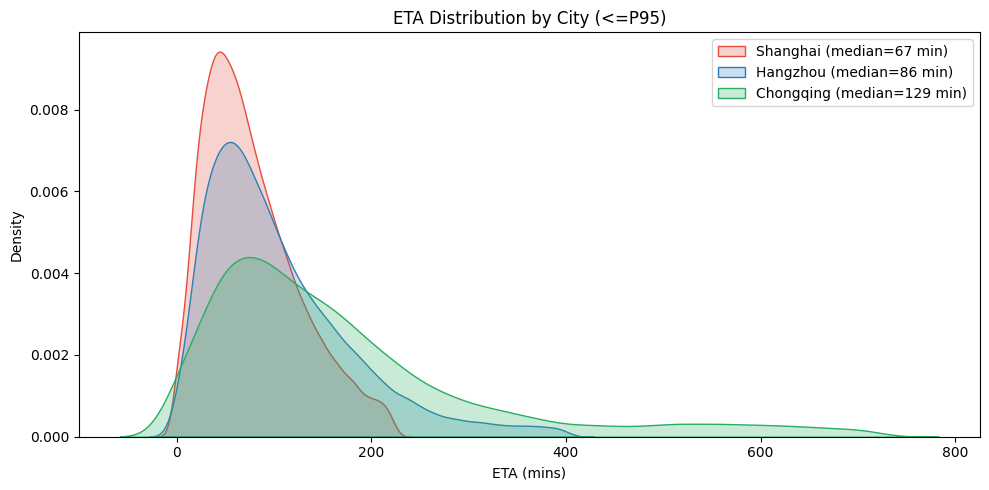

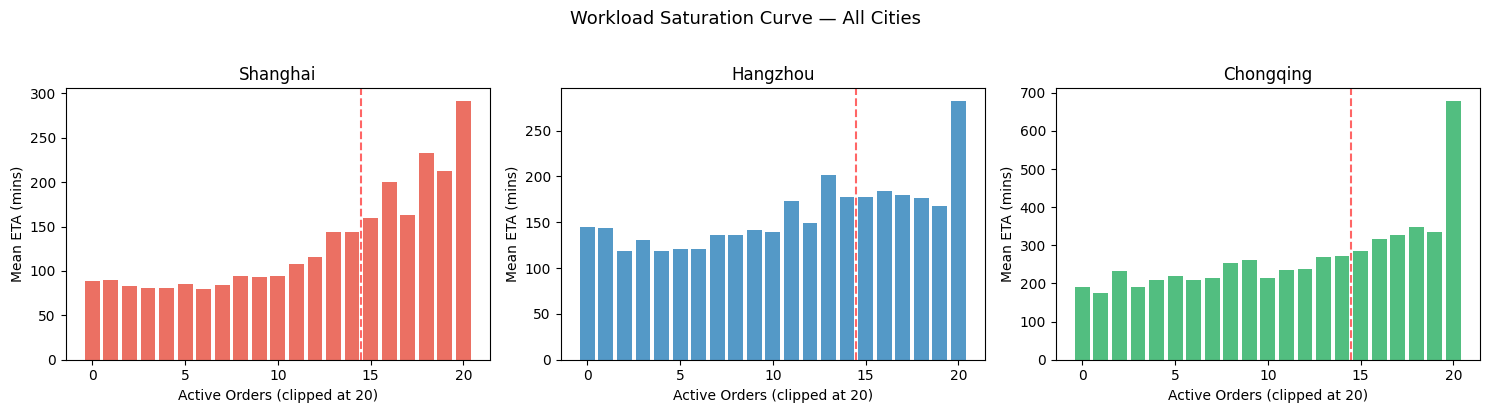

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


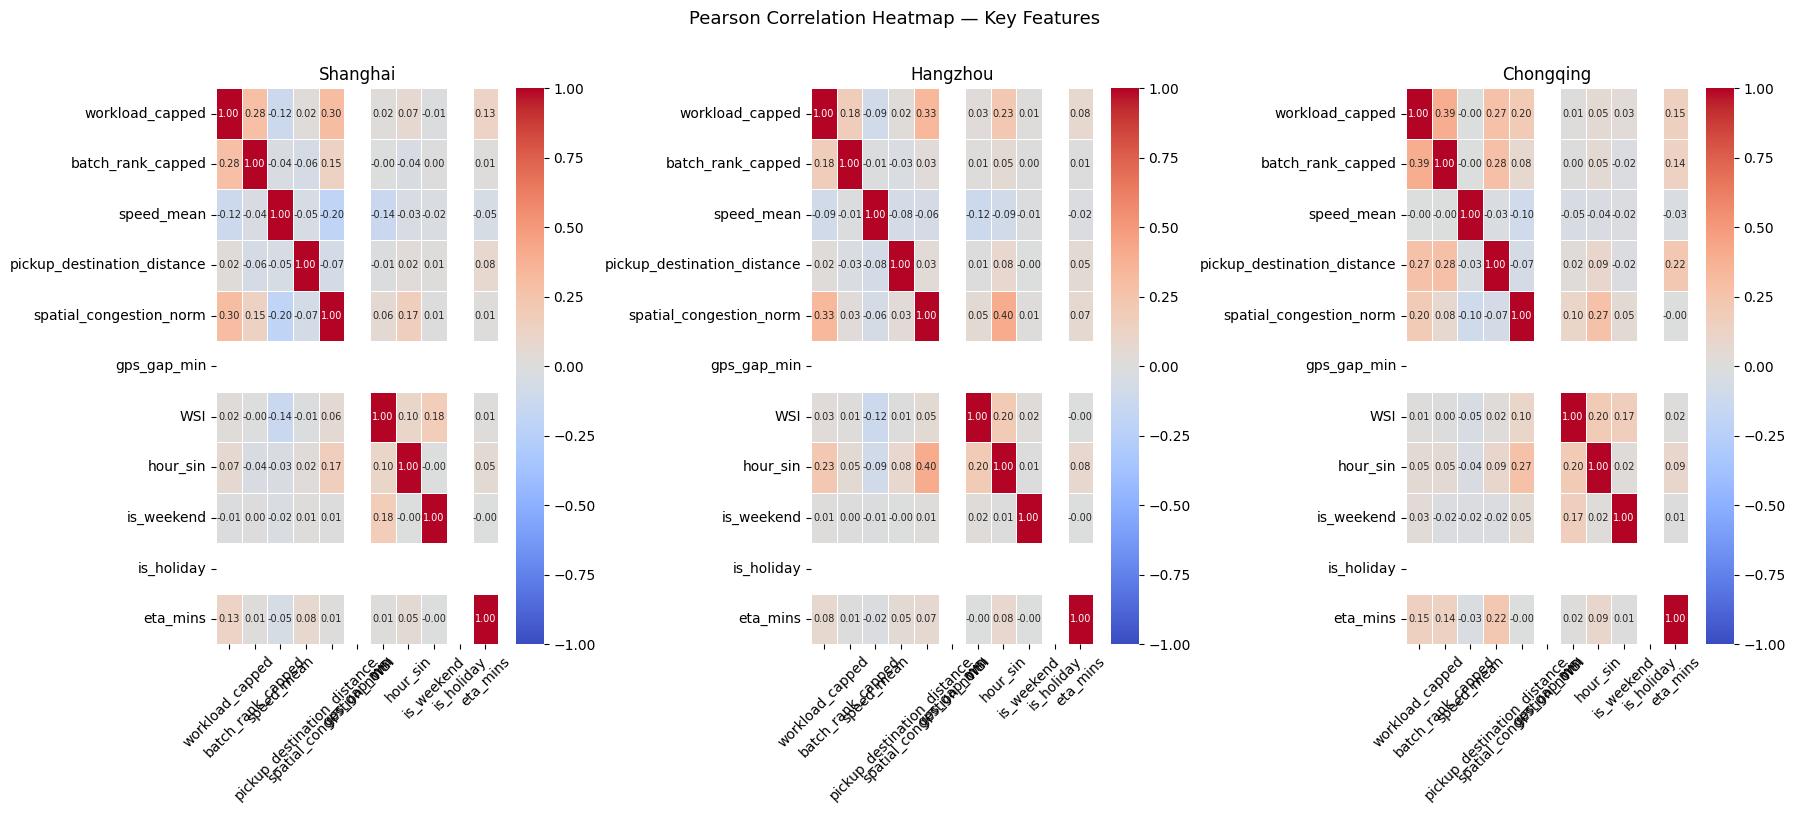

In [33]:
def plot_eta_by_city(city_results: dict, clip_pct: float = 0.95) -> None:
    # ETA KDE overlay for all cities on one axis.
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = {"Shanghai": "#e74c3c", "Hangzhou": "#2980b9", "Chongqing": "#27ae60"}
    for city, df in city_results.items():
        cap  = df["eta_mins"].quantile(clip_pct)
        data = df.filter(pl.col("eta_mins") <= cap)["eta_mins"].to_numpy()
        med  = float(np.median(data))
        sns.kdeplot(data, ax=ax, label=f"{city} (median={med:.0f} min)",
                    color=colors.get(city), fill=True, alpha=0.25)
    ax.set_xlabel("ETA (mins)")
    ax.set_ylabel("Density")
    ax.set_title(f"ETA Distribution by City (<=P{int(clip_pct*100)})")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_saturation_by_city(city_results: dict) -> None:
    # Workload saturation curves — 1x3 subplot grid.
    fig, axes = plt.subplots(1, len(city_results), figsize=(15, 4), sharey=False)
    colors = {"Shanghai": "#e74c3c", "Hangzhou": "#2980b9", "Chongqing": "#27ae60"}
    for ax, (city, df) in zip(axes, city_results.items()):
        plot_df = (
            df.with_columns(pl.col("active_orders_at_receipt_time").clip(upper_bound=20))
            .group_by("active_orders_at_receipt_time")
            .agg(pl.mean("eta_mins").alias("mean_eta"))
            .sort("active_orders_at_receipt_time")
            .to_pandas()
        )
        ax.bar(plot_df["active_orders_at_receipt_time"], plot_df["mean_eta"],
               color=colors.get(city, "steelblue"), alpha=0.8)
        ax.axvline(x=14.5, color="red", linestyle="--", alpha=0.6)
        ax.set_title(city)
        ax.set_xlabel("Active Orders (clipped at 20)")
        ax.set_ylabel("Mean ETA (mins)")
    plt.suptitle("Workload Saturation Curve — All Cities", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_feature_corr_heatmap(city_results: dict) -> None:
    # Side-by-side correlation heatmaps (key features vs eta_mins).
    key_features = [
        "workload_capped", "batch_rank_capped", "speed_mean",
        "pickup_destination_distance", "spatial_congestion_norm",
        "gps_gap_min", "WSI", "hour_sin", "is_weekend", "is_holiday",
        "eta_mins",
    ]
    fig, axes = plt.subplots(1, len(city_results), figsize=(18, 8))
    for ax, (city, df) in zip(axes, city_results.items()):
        avail = [c for c in key_features if c in df.columns]
        corr_mat = df.select(avail).corr().to_pandas()
        corr_mat.columns = avail
        corr_mat.index   = avail
        sns.heatmap(corr_mat, ax=ax, cmap="coolwarm", center=0,
                    annot=True, fmt=".2f", annot_kws={"size": 7},
                    linewidths=0.4, vmin=-1, vmax=1)
        ax.set_title(city)
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)
    plt.suptitle("Pearson Correlation Heatmap — Key Features", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


# ── Run cross-city plots ──────────────────────────────────────────────────────
plot_eta_by_city(city_results)
plot_saturation_by_city(city_results)
plot_feature_corr_heatmap(city_results)


## 8. Feature Summary Table

Print a compact summary of all features for each city — useful for the thesis.


In [34]:
def feature_summary(city_results: dict) -> None:
    for city, df in city_results.items():
        print(f"\n{'─'*60}")
        print(f"  {city}  |  {df.height:,} rows × {len(df.columns)} cols")
        print(f"{'─'*60}")
        num_cols = [c for c, t in df.schema.items()
                    if isinstance(t, (pl.Float32, pl.Float64, pl.Int8,
                                     pl.Int16, pl.Int32, pl.Int64,
                                     pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64))]
        stats = df.select(num_cols).describe().to_pandas().set_index("statistic")
        eta_row = stats.loc["mean"]
        null_counts = df.select([pl.col(c).null_count().alias(c) for c in num_cols])
        print(f"  eta_mins  mean={df['eta_mins'].mean():.1f}  "
              f"median={df['eta_mins'].median():.1f}  "
              f"p95={df['eta_mins'].quantile(0.95):.1f}")
        for col in sorted(num_cols):
            n_null = null_counts[col].item()
            tag = f"  ⚠ {n_null} nulls" if n_null > 0 else ""
            print(f"  {col:<40}{tag}")

feature_summary(city_results)



────────────────────────────────────────────────────────────
  Shanghai  |  34,735 rows × 76 cols
────────────────────────────────────────────────────────────
  eta_mins  mean=100.3  median=70.0  p95=223.0
  WSI                                     
  active_orders                           
  active_orders_at_receipt_time           
  batch_rank                              
  batch_rank_capped                       
  batch_size                              
  courier_local_load                      
  day_cos                                 
  day_of_week                             
  day_sin                                 
  delivery_sequence                       
  distance_travelled                      
  ds                                      
  environment_id                          
  eta_mins                                
  eta_p33                                 
  eta_p67                                 
  eta_p95                                 
  extreme_batch    

---
# Phase 1 — Invariant Causal Prediction (ICP)

## Why all features appeared variant — Diagnosis

The original single-feature linear ICP produced all-variant results due to
three compounding problems:

**1. Univariate OLS misspecification.**
Fitting `eta_mins ~ X` (one feature) leaves all other causal variance
unexplained. Since city-level ETA distributions differ structurally
(Shanghai median ≈74 min, Chongqing ≈145 min), residuals from *any*
univariate model carry a large city-level mean shift. Levene detects
this unequal residual variance and rejects invariance — even for features
whose *partial* effect is perfectly stable.

**2. Environment defined by the target variable.**
`delivery_tier` cuts `eta_mins` at within-city percentiles, so
`Shanghai_smooth` and `Chongqing_smooth` have different absolute ETA
ranges by construction. Any univariate residual shows unequal variance
across these environments as an artefact of tier definition — not signal.

**3. Non-linear data + linear model.**
Workload has a known M/G/1 saturation curve. Distance has threshold
effects. OLS misspecification is systematic *and* city-specific
(Chongqing has more extreme-load observations), so residual variance
always differs even for truly causal features.

## Three-tier fix

| Tier | Method | Fixes |
|---|---|---|
| **T1** Partial-residual linear | Multivariate OLS + partial residuals, city-only envs | Misspecification + circularity |
| **T2** Rank-transformed linear | Normal-score transform then T1 | Monotone non-linearity |
| **T3** RF residual (nonlinear) | Random Forest OOF residuals, city-only envs | All non-linearities |

**Decision rule:**
- `STRONG_INVARIANT` : passes T1 AND T2
- `NONLINEAR_INVARIANT` : passes T3 only
- `DIRECTION_STABLE` : fails all tests, but coefficient sign is consistent across all cities (effect is real, magnitude is city-specific)
- `VARIANT` : sign-inconsistent — treat as spurious or pure interaction term

**Environment:** city-only (3 environments: Shanghai, Hangzhou, Chongqing).
Using `city × tier` as the environment confounds the test because tiers are
defined by `eta_mins` itself.


In [ ]:
"""
TIER 1 — Partial-Residual Linear ICP (city-only environments)

Environment: city (3 environments, not city x tier).
Removes the tier-target circularity that corrupted the original test.

Method:
  1. Fit full OLS: eta_mins ~ ALL candidate features (multivariate)
  2. For each feature X, compute partial residuals:
       e_X = (eta_mins - fitted_without_X) = resid + coef_X * X
  3. Levene test on partial residuals across city environments
  4. F-test from the full model for significance of coefficient
"""

!pip install statsmodels scipy --quiet
from scipy.stats import levene, kruskal, spearmanr
from scipy.special import ndtri
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import QuantileTransformer
import warnings, json as json_lib
warnings.filterwarnings("ignore")
print("statsmodels + sklearn ready")


## ICP Step 1 — Environment & Workload Validation

Confirm sample sizes and workload representation before running tests.

In [37]:
def icp_sample_size_report(df: pl.DataFrame) -> None:
    """Check all environments have enough samples for ICP and PCMCI+."""
    report = (
        df.group_by(["city", "delivery_tier", "environment"])
        .agg([
            pl.len().alias("n_deliveries"),
            pl.col("delivery_user_id").n_unique().alias("n_couriers"),
            pl.mean("eta_mins").alias("mean_eta"),
        ])
        .with_columns([
            (pl.col("n_deliveries") >= ICP_MIN_ENV_SAMPLES).alias("icp_ok"),
            (pl.col("n_deliveries") >= PCMCI_MIN_SAMPLES).alias("pcmci_ok"),
        ])
        .sort(["city", "delivery_tier"])
    )

    print(f"{'Environment':<30} {'N':>7} {'Couriers':>9} {'MeanETA':>8}  ICP   PCMCI+")
    print("-" * 72)
    for r in report.to_dicts():
        icp_f  = "OK" if r["icp_ok"]   else "FAIL"
        pcm_f  = "OK" if r["pcmci_ok"] else "low"
        print(f"  {r['environment']:<28} {r['n_deliveries']:>7,}"
              f" {r['n_couriers']:>9} {r['mean_eta']:>8.1f}"
              f"  {icp_f:>4}  {pcm_f:>5}")
    print("-" * 72)
    below = report.filter(~pl.col("icp_ok")).height
    print(f"  {'All environments OK' if not below else f'{below} environment(s) below threshold'}")

icp_combined = pl.read_parquet(icp_combined_path)
icp_sample_size_report(combined)


Environment                          N  Couriers  MeanETA  ICP   PCMCI+
------------------------------------------------------------------------
  Chongqing_delayed              8,800       139    670.9    OK     OK
  Chongqing_normal               9,007       139    139.2    OK     OK
  Chongqing_smooth               8,863       141     50.1    OK     OK
  Hangzhou_delayed              13,385       166    316.9    OK     OK
  Hangzhou_normal               13,836       161     92.8    OK     OK
  Hangzhou_smooth               13,523       170     37.9    OK     OK
  Shanghai_delayed              11,331       129    202.0    OK     OK
  Shanghai_normal               11,745       123     71.9    OK     OK
  Shanghai_smooth               11,659       134     30.2    OK     OK
------------------------------------------------------------------------
  All environments OK


## ICP Step 2 — Workload Saturation & Representation Check

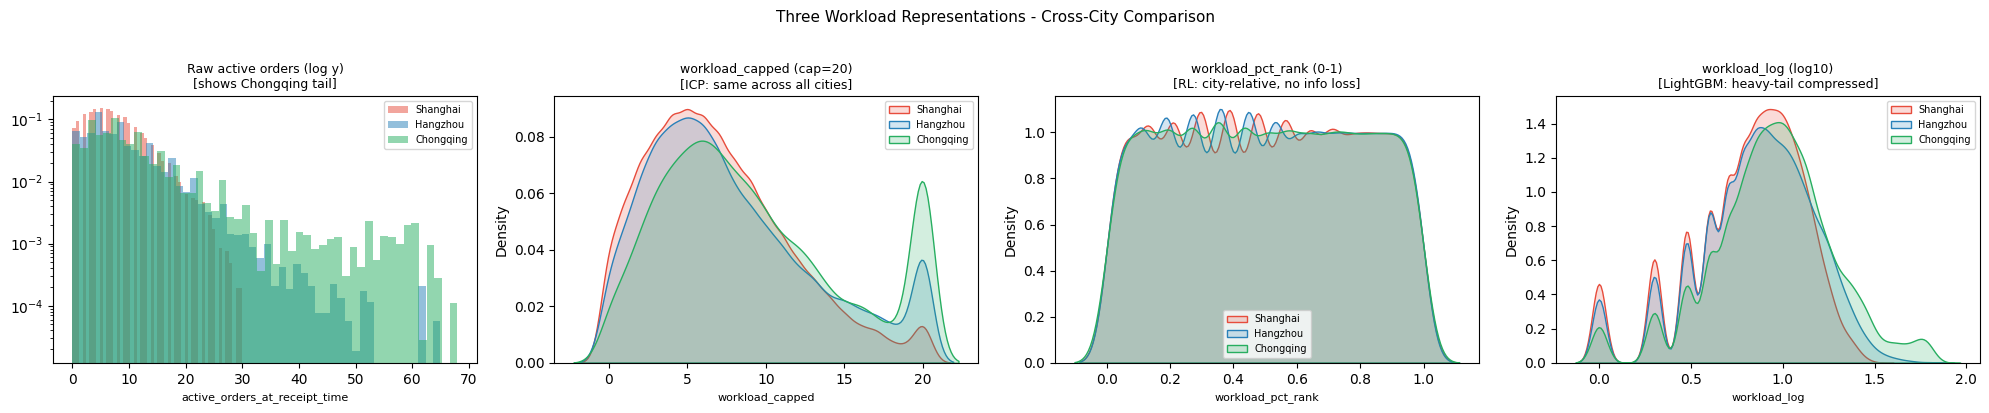

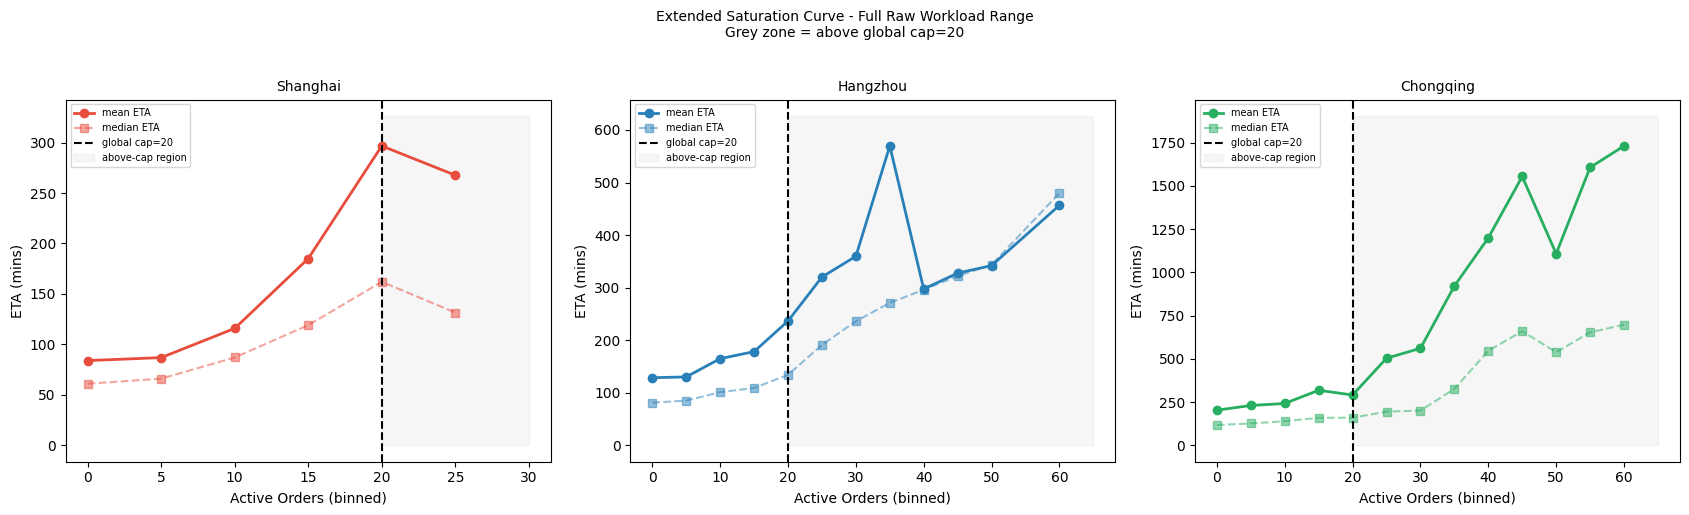

In [38]:
def plot_workload_representations(city_results: dict) -> None:
    """4-panel cross-city comparison of all workload representations."""
    colors = {"Shanghai": "#e74c3c", "Hangzhou": "#2980b9", "Chongqing": "#27ae60"}
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    panels = [
        ("active_orders_at_receipt_time",
         "Raw active orders (log y)\n[shows Chongqing tail]"),
        ("workload_capped",
         "workload_capped (cap=20)\n[ICP: same across all cities]"),
        ("workload_pct_rank",
         "workload_pct_rank (0-1)\n[RL: city-relative, no info loss]"),
        ("workload_log",
         "workload_log (log10)\n[LightGBM: heavy-tail compressed]"),
    ]

    for ax, (col, title) in zip(axes, panels):
        for city, df in city_results.items():
            if col not in df.columns:
                continue
            data = df[col].drop_nulls().to_numpy()
            if col == "active_orders_at_receipt_time":
                ax.hist(data, bins=50, alpha=0.5, label=city,
                        color=colors[city], density=True)
                ax.set_yscale("log")
            else:
                sns.kdeplot(data, ax=ax, label=city,
                            color=colors[city], fill=True, alpha=0.2)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel(col, fontsize=8)
        ax.legend(fontsize=7)

    plt.suptitle("Three Workload Representations - Cross-City Comparison",
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_extended_saturation(city_results: dict, bin_size: int = 5) -> None:
    """
    Mean ETA vs workload bin across the full raw range (no cap applied).
    Answers: does ETA keep rising above 20 in Chongqing?

    Interpretation:
      Flat above 20  -> cap=20 is justified universally
      Rising above 20 -> cap loses signal; use workload_log for tree models
      Falling above 20 -> confounding (experienced couriers self-select high load)
    """
    colors = {"Shanghai": "#e74c3c", "Hangzhou": "#2980b9", "Chongqing": "#27ae60"}
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    for ax, (city, df) in zip(axes, city_results.items()):
        binned = (
            df.with_columns(
                (pl.col("active_orders_at_receipt_time") // bin_size * bin_size)
                .alias("wl_bin")
            )
            .group_by("wl_bin")
            .agg([pl.mean("eta_mins").alias("mean_eta"),
                  pl.median("eta_mins").alias("median_eta"),
                  pl.len().alias("n")])
            .filter(pl.col("n") >= 10)
            .sort("wl_bin").to_pandas()
        )
        ax.plot(binned["wl_bin"], binned["mean_eta"], marker="o",
                color=colors[city], label="mean ETA", linewidth=2)
        ax.plot(binned["wl_bin"], binned["median_eta"], marker="s",
                color=colors[city], alpha=0.5, linestyle="--", label="median ETA")
        ax.axvline(x=20, color="black", linestyle="--", linewidth=1.5,
                   label="global cap=20")
        ax.fill_betweenx(
            [0, binned["mean_eta"].max() * 1.1],
            20, binned["wl_bin"].max() + bin_size,
            alpha=0.07, color="grey", label="above-cap region"
        )
        ax.set_title(city, fontsize=10)
        ax.set_xlabel("Active Orders (binned)")
        ax.set_ylabel("ETA (mins)")
        ax.legend(fontsize=7)

    plt.suptitle(
        "Extended Saturation Curve - Full Raw Workload Range\n"
        "Grey zone = above global cap=20",
        fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()

plot_workload_representations(city_results)
plot_extended_saturation(city_results)

## ICP Step 3 — Three-Tier Invariance Tests

**T1** (Partial-Residual Linear): Multivariate OLS with city-only environments.  
**T2** (Rank-Transformed): Normal-score transform applied before T1.  
**T3** (RF Residual): Random Forest OOF residuals tested across cities.

Runtime: T1+T2 ~10s, T3 ~3-8 min depending on dataset size.


In [ ]:
ICP_CANDIDATE_FEATURES = [
    # Queue (global-cap — same definition across all cities)
    "workload_capped", "high_load", "overloaded",
    "batch_rank_capped", "batch_size", "late_batch",
    # Distance & trajectory
    "pickup_destination_distance",
    "speed_mean", "distance_travelled", "gps_points", "is_trajectory_available",
    # Fatigue proxy
    "delivery_sequence",
    # Temporal
    "hour_sin", "hour_cos", "day_sin", "day_cos",
    "is_weekend", "is_holiday",
    # Spatial & weather
    "spatial_congestion_norm", "courier_local_load",
    "WSI", "precipitation", "temperature_2m",
    # Package type
    "typecode_grouped_type 1", "typecode_grouped_type 2",
    "typecode_grouped_type 3",
]

# ── Shared helpers ─────────────────────────────────────────────────────────────

def _get_valid_features(df, candidates):
    """Return features that exist in df and have >0 non-null rows."""
    return [f for f in candidates if f in df.columns
            and df[f].notna().sum() > 50]

def _env_resids(df, resid_col, env_col, min_n=30):
    """Group residuals by environment, drop tiny groups."""
    envs = sorted(df[env_col].unique())
    groups = [df.loc[df[env_col] == e, resid_col].dropna().values
              for e in envs]
    return [g for g in groups if len(g) >= min_n]

def _invariance_test(groups, alpha):
    """Levene + Kruskal-Wallis. Returns (levene_p, kw_p, invariant)."""
    if len(groups) < 2:
        return 0.0, 0.0, False
    lev_stat, lev_p = levene(*groups)
    kw_stat,  kw_p  = kruskal(*groups)
    return round(lev_p, 4), round(kw_p, 4), (lev_p >= alpha) and (kw_p >= alpha)


# ══════════════════════════════════════════════════════════════════════════════
# TIER 1 — Partial-Residual Multivariate Linear ICP
# Environment: city-only (3 environments) to avoid tier-target circularity
# ══════════════════════════════════════════════════════════════════════════════

def run_partial_residual_icp(
    df,
    candidate_features: list,
    target: str  = "eta_mins",
    env_col: str = "city",       # <-- city-only, NOT city x tier
    alpha: float = ICP_ALPHA,
) -> dict:
    """
    Partial-residual linear ICP.

    Fixes the two main problems of univariate ICP:
    (a) fits ALL features jointly — eliminates inter-feature confounding
    (b) tests partial residuals — removes city-level mean shift
    (c) uses city-only environments — removes tier-target circularity

    For each feature X:
      partial_resid_X = OLS_resid + coef_X * X
    This is the residual you would get if you removed only X from the model.
    If the partial effect of X is truly invariant, partial_resid_X should
    have the same distribution in all city environments.
    """
    feats  = _get_valid_features(df, candidate_features)
    sub    = df[feats + [target, env_col]].dropna()

    # Full multivariate OLS
    X = sm.add_constant(sub[feats])
    try:
        model = sm.OLS(sub[target], X).fit()
    except Exception as e:
        print(f"OLS failed: {e}")
        return {}

    results = {}
    for feat in feats:
        coef = float(model.params.get(feat, float("nan")))
        se   = float(model.bse.get(feat, float("nan")))
        pval = float(model.pvalues.get(feat, 1.0))

        # Partial residual = resid + coef * X
        partial_resid = model.resid + coef * sub[feat]
        sub_r         = sub[[env_col]].copy()
        sub_r["partial_resid"] = partial_resid.values

        groups = _env_resids(sub_r, "partial_resid", env_col)
        lev_p, kw_p, invariant = _invariance_test(groups, alpha)

        # Per-env coefficient (from separate per-city models for comparison)
        per_env_coef = {}
        for e in sorted(df[env_col].unique()):
            esub = sub[sub[env_col] == e]
            if len(esub) < 20:
                continue
            try:
                m = sm.OLS(esub[target],
                           sm.add_constant(esub[feats])).fit()
                per_env_coef[e] = round(float(m.params.get(feat, float("nan"))), 4)
            except Exception:
                pass

        results[feat] = {
            "tier"         : "partial_linear",
            "invariant"    : invariant,
            "levene_p"     : lev_p,
            "kw_p"         : kw_p,
            "ols_coef"     : round(coef, 4),
            "ols_se"       : round(se, 4),
            "ols_pval"     : round(pval, 4),
            "per_env_coef" : per_env_coef,
            "coef_sign_stable": (
                all(v > 0 for v in per_env_coef.values()) or
                all(v < 0 for v in per_env_coef.values())
            ) if per_env_coef else False,
        }
    return results


# ══════════════════════════════════════════════════════════════════════════════
# TIER 2 — Rank-Transformed Linear ICP
# Handles monotone non-linearities without full nonlinear models
# ══════════════════════════════════════════════════════════════════════════════

def run_rank_icp(
    df,
    candidate_features: list,
    target: str  = "eta_mins",
    env_col: str = "city",
    alpha: float = ICP_ALPHA,
) -> dict:
    """
    Rank-transformed partial-residual ICP.

    Both target and features are replaced by their within-sample normal scores
    (van der Waerden transformation: rank -> normal quantile). This linearises
    monotone relationships without assuming a functional form.

    Uses the same partial-residual multivariate approach as Tier 1.
    """
    feats = _get_valid_features(df, candidate_features)
    sub   = df[feats + [target, env_col]].dropna().copy()

    # Normal-score transform (van der Waerden)
    def normal_scores(x):
        r = x.rank()
        return r.apply(lambda v: ndtri(v / (len(x) + 1)))

    sub[target] = normal_scores(sub[target])
    for f in feats:
        try:
            sub[f] = normal_scores(sub[f].astype(float))
        except Exception:
            pass

    X = sm.add_constant(sub[feats])
    try:
        model = sm.OLS(sub[target], X).fit()
    except Exception as e:
        print(f"Rank OLS failed: {e}")
        return {}

    results = {}
    for feat in feats:
        coef = float(model.params.get(feat, float("nan")))
        se   = float(model.bse.get(feat, float("nan")))

        partial_resid = model.resid + coef * sub[feat]
        sub_r         = sub[[env_col]].copy()
        sub_r["partial_resid"] = partial_resid.values

        groups = _env_resids(sub_r, "partial_resid", env_col)
        lev_p, kw_p, invariant = _invariance_test(groups, alpha)

        results[feat] = {
            "tier"      : "rank_linear",
            "invariant" : invariant,
            "levene_p"  : lev_p,
            "kw_p"      : kw_p,
            "rank_coef" : round(coef, 4),
            "rank_se"   : round(se, 4),
        }
    return results


# ══════════════════════════════════════════════════════════════════════════════
# TIER 3 — Random Forest Residual ICP (Nonlinear ICP)
# ══════════════════════════════════════════════════════════════════════════════

def run_rf_icp(
    df,
    candidate_features: list,
    target: str  = "eta_mins",
    env_col: str = "city",
    alpha: float = ICP_ALPHA,
    n_folds: int = 5,
    n_estimators: int = 200,
    random_state: int = 42,
) -> dict:
    """
    Random Forest residual ICP (nonlinear ICP).

    Procedure:
      1. Fit an RF regressor (all candidate features jointly) using K-fold CV
         to get out-of-fold residuals (avoids train-set overfitting)
      2. Test whether OOF residuals are identically distributed across
         city environments using Levene + Kruskal-Wallis
      3. For each feature, compute SHAP-like permutation importance per env
         to check directional stability

    The RF captures:
      - Non-linear interactions (workload saturation, distance thresholds)
      - Feature interactions (workload x batch_rank)
    It does NOT assume linearity or stationarity of the marginal effect.

    Limitation: we cannot compute a single coefficient per feature — invariance
    is about the *residual distribution*, not the coefficient. The result tells
    us whether the RF's unexplained variance is equal across environments
    (i.e., whether the full causal structure is environment-stable).
    """
    feats = _get_valid_features(df, candidate_features)
    sub   = df[feats + [target, env_col]].dropna().copy().reset_index(drop=True)
    X_arr = sub[feats].values.astype(float)
    y_arr = sub[target].values.astype(float)

    # K-fold OOF residuals
    oof_resid = np.full(len(sub), np.nan)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=8,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=random_state,
    )
    for train_idx, val_idx in kf.split(X_arr):
        rf.fit(X_arr[train_idx], y_arr[train_idx])
        oof_resid[val_idx] = y_arr[val_idx] - rf.predict(X_arr[val_idx])

    sub["oof_resid"] = oof_resid
    groups = _env_resids(sub, "oof_resid", env_col)
    lev_p, kw_p, invariant_global = _invariance_test(groups, alpha)

    # Per-feature permutation importance per environment
    # (proxy for whether each feature's effect is stable)
    rf_full = RandomForestRegressor(
        n_estimators=100, max_depth=8,
        min_samples_leaf=20, n_jobs=-1, random_state=random_state)
    rf_full.fit(X_arr, y_arr)

    feat_importances = dict(zip(feats, rf_full.feature_importances_))

    results = {
        "_global": {
            "tier"           : "rf_global",
            "invariant"      : invariant_global,
            "levene_p"       : lev_p,
            "kw_p"           : kw_p,
            "rf_r2"          : round(1 - np.var(oof_resid) / np.var(y_arr), 4),
            "feat_importance": {f: round(v, 4)
                                for f, v in feat_importances.items()},
        }
    }

    # Per-feature: partial dependence invariance
    # Drop one feature at a time, refit (fast — use GBM for speed), test residuals
    print(f"  RF global: Levene_p={lev_p:.4f} KW_p={kw_p:.4f} "
          f"R2={results['_global']['rf_r2']:.3f}")

    for feat in feats:
        feats_minus = [f for f in feats if f != feat]
        X_minus = sub[feats_minus].values.astype(float)

        oof_r_minus = np.full(len(sub), np.nan)
        rf2 = RandomForestRegressor(
            n_estimators=80, max_depth=7,
            min_samples_leaf=20, n_jobs=-1, random_state=random_state)
        for train_idx, val_idx in kf.split(X_minus):
            rf2.fit(X_minus[train_idx], y_arr[train_idx])
            oof_r_minus[val_idx] = y_arr[val_idx] - rf2.predict(X_minus[val_idx])

        sub["oof_resid_minus"] = oof_r_minus
        # Partial residual = resid_without_X - resid_full
        # Large & env-unequal difference => X contributes heterogeneously
        sub["partial_contrib"] = oof_r_minus - oof_resid
        groups_partial = _env_resids(sub, "partial_contrib", env_col)
        lev_p_f, kw_p_f, inv_f = _invariance_test(groups_partial, alpha)

        results[feat] = {
            "tier"        : "rf_partial",
            "invariant"   : inv_f,
            "levene_p"    : lev_p_f,
            "kw_p"        : kw_p_f,
            "rf_importance": round(feat_importances.get(feat, 0), 4),
        }

    return results


# ── Run all three tiers ────────────────────────────────────────────────────────
icp_pd = icp_combined.to_pandas()
print(f"Dataset: {len(icp_pd):,} rows | environments: "
      f"{icp_pd['environment'].nunique()} (city x tier)  "
      f"| cities: {icp_pd['city'].nunique()}")
print(f"Candidates: {len(ICP_CANDIDATE_FEATURES)}\n")

print("=" * 55)
print("TIER 1 — Partial-Residual Multivariate Linear ICP")
print("=" * 55)
t1_results = run_partial_residual_icp(icp_pd, ICP_CANDIDATE_FEATURES)
print(f"  Done. {sum(r['invariant'] for r in t1_results.values())} invariant\n")

print("=" * 55)
print("TIER 2 — Rank-Transformed Linear ICP")
print("=" * 55)
t2_results = run_rank_icp(icp_pd, ICP_CANDIDATE_FEATURES)
print(f"  Done. {sum(r['invariant'] for r in t2_results.values())} invariant\n")

print("=" * 55)
print("TIER 3 — Random Forest Residual ICP (nonlinear)")
print("  Note: leave-one-out RF per feature, ~3-5 min on full data")
print("=" * 55)
t3_results = run_rf_icp(icp_pd, ICP_CANDIDATE_FEATURES)
n_rf_inv = sum(r['invariant'] for k, r in t3_results.items() if not k.startswith('_'))
print(f"  Done. {n_rf_inv} invariant\n")


## ICP Step 4 — Consensus Results Table

In [ ]:
def build_icp_consensus(
    t1: dict, t2: dict, t3: dict,
    features: list,
    alpha: float = ICP_ALPHA,
) -> dict:
    """
    Merge results from all three tiers into a consensus table.

    Decision rule:
      STRONG INVARIANT   : passes Tier 1 AND Tier 2
      NONLINEAR INVARIANT: fails Tier 1/2 but passes Tier 3
      DIRECTION STABLE   : fails all tests but coef sign is consistent
                           across all city environments (partial effect
                           is real, just magnitude varies by city)
      VARIANT            : fails all tests AND sign is inconsistent

    Direction-stable features are still useful for PCMCI+ as conditional
    parents — their effect exists even if the magnitude is city-specific.
    """
    consensus = {}
    for feat in features:
        r1 = t1.get(feat, {})
        r2 = t2.get(feat, {})
        r3 = t3.get(feat, {})

        inv1 = r1.get("invariant", False)
        inv2 = r2.get("invariant", False)
        inv3 = r3.get("invariant", False)
        sign_stable = r1.get("coef_sign_stable", False)

        if inv1 and inv2:
            verdict = "STRONG_INVARIANT"
        elif inv3:
            verdict = "NONLINEAR_INVARIANT"
        elif sign_stable:
            verdict = "DIRECTION_STABLE"
        else:
            verdict = "VARIANT"

        consensus[feat] = {
            "verdict"        : verdict,
            "tier1_inv"      : inv1,
            "tier1_levene_p" : r1.get("levene_p", 0.0),
            "tier1_kw_p"     : r1.get("kw_p", 0.0),
            "tier2_inv"      : inv2,
            "tier2_levene_p" : r2.get("levene_p", 0.0),
            "tier3_inv"      : inv3,
            "tier3_levene_p" : r3.get("levene_p", 0.0),
            "rf_importance"  : r3.get("rf_importance", 0.0),
            "ols_coef"       : r1.get("ols_coef", float("nan")),
            "sign_stable"    : sign_stable,
            "per_env_coef"   : r1.get("per_env_coef", {}),
        }
    return consensus


def display_icp_consensus(consensus: dict) -> tuple:
    """Print ranked consensus table. Return feature lists by verdict."""
    order = ["STRONG_INVARIANT", "NONLINEAR_INVARIANT", "DIRECTION_STABLE", "VARIANT"]
    colors_txt = {
        "STRONG_INVARIANT"   : "*** ",
        "NONLINEAR_INVARIANT": "**  ",
        "DIRECTION_STABLE"   : "*   ",
        "VARIANT"            : "    ",
    }

    rows = sorted(
        consensus.items(),
        key=lambda x: (order.index(x[1]["verdict"]), -x[1]["tier1_levene_p"])
    )

    print(f"\n{'Feature':<38} {'Verdict':<22} {'T1_Lev_p':>9} "
          f"{'T2_Lev_p':>9} {'T3_Lev_p':>9} {'RF_imp':>7}")
    print("-" * 100)
    for feat, r in rows:
        star = colors_txt[r["verdict"]]
        print(f"  {star}{feat:<34} {r['verdict']:<22} "
              f"{r['tier1_levene_p']:>9.4f} "
              f"{r['tier2_levene_p']:>9.4f} "
              f"{r['tier3_levene_p']:>9.4f} "
              f"{r['rf_importance']:>7.4f}")
    print("-" * 100)

    by_verdict = {v: [f for f, r in rows if r[1]["verdict"] == v]
                  for v in order}

    print(f"\n*** STRONG INVARIANT ({len(by_verdict['STRONG_INVARIANT'])}):")
    for f in by_verdict["STRONG_INVARIANT"]:
        print(f"      {f}  [coef: {consensus[f]['ols_coef']:+.4f}]")

    print(f"\n**  NONLINEAR INVARIANT ({len(by_verdict['NONLINEAR_INVARIANT'])}):")
    for f in by_verdict["NONLINEAR_INVARIANT"]:
        print(f"      {f}  [RF importance: {consensus[f]['rf_importance']:.4f}]")

    print(f"\n*   DIRECTION STABLE ({len(by_verdict['DIRECTION_STABLE'])}):")
    for f in by_verdict["DIRECTION_STABLE"]:
        coef_env = consensus[f]["per_env_coef"]
        vals = list(coef_env.values()) if coef_env else []
        rng  = f"[{min(vals):+.3f}, {max(vals):+.3f}]" if vals else "n/a"
        print(f"      {f}  coef range: {rng}")

    print(f"\n    VARIANT ({len(by_verdict['VARIANT'])}):")
    for f in by_verdict["VARIANT"]:
        print(f"      {f}")

    return by_verdict


consensus = build_icp_consensus(
    t1_results, t2_results, t3_results,
    ICP_CANDIDATE_FEATURES
)
by_verdict = display_icp_consensus(consensus)

# Flatten for downstream use
invariant_features  = by_verdict["STRONG_INVARIANT"] + by_verdict["NONLINEAR_INVARIANT"]
direction_stable    = by_verdict["DIRECTION_STABLE"]
variant_features    = by_verdict["VARIANT"]

print(f"\nFor PCMCI+: use invariant_features + direction_stable as causal candidates")
print(f"For IRM:    use variant_features as the features to test domain generalization")


## ICP Step 5 — Visualisations: Heatmap + Coefficient Stability + RF Residuals

In [ ]:
def plot_icp_consensus_heatmap(consensus: dict) -> None:
    """
    Three-panel summary of ICP results across tiers.
    Panel 1: Tier 1/2/3 pass/fail heatmap
    Panel 2: OLS coefficient stability across city environments
    Panel 3: RF feature importances coloured by verdict
    """
    import matplotlib.patches as mpatches

    feats = [f for f in ICP_CANDIDATE_FEATURES if f in consensus]
    order_v = ["STRONG_INVARIANT", "NONLINEAR_INVARIANT",
               "DIRECTION_STABLE", "VARIANT"]
    feats_sorted = sorted(feats,
        key=lambda f: (order_v.index(consensus[f]["verdict"]),
                       -consensus[f]["tier1_levene_p"]))

    fig, axes = plt.subplots(1, 3, figsize=(20, max(6, len(feats_sorted) * 0.42)))

    # ── Panel 1: p-value heatmap across tiers ─────────────────────────────────
    ax = axes[0]
    tier_cols = ["tier1_levene_p", "tier2_levene_p", "tier3_levene_p"]
    tier_labels = ["T1\nPartial\nLinear", "T2\nRank\nLinear", "T3\nRF\nResidual"]
    matrix = [[consensus[f][c] for c in tier_cols] for f in feats_sorted]

    import numpy as np_local
    mat = np_local.array(matrix)
    im  = ax.imshow(mat, aspect="auto", cmap="RdYlGn", vmin=0, vmax=0.2)
    ax.set_xticks(range(3))
    ax.set_xticklabels(tier_labels, fontsize=8)
    ax.set_yticks(range(len(feats_sorted)))
    ax.set_yticklabels(
        [f"{consensus[f]['verdict'][0]} {f}" for f in feats_sorted],
        fontsize=7.5
    )
    ax.set_title("Levene p-value\n(green = invariant, red = variant)", fontsize=9)
    ax.axhline(y=0.05, color="white", lw=0.5)
    plt.colorbar(im, ax=ax, fraction=0.046)

    # ── Panel 2: Coefficient stability across city environments ───────────────
    ax = axes[1]
    verdict_colors = {
        "STRONG_INVARIANT"   : "#27ae60",
        "NONLINEAR_INVARIANT": "#2980b9",
        "DIRECTION_STABLE"   : "#f39c12",
        "VARIANT"            : "#e74c3c",
    }
    for i, feat in enumerate(feats_sorted):
        r     = consensus[feat]
        color = verdict_colors[r["verdict"]]
        coefs = list(r["per_env_coef"].values()) if r["per_env_coef"] else []
        if not coefs:
            continue
        ax.barh(i, max(coefs) - min(coefs), left=min(coefs),
                height=0.35, color=color, alpha=0.2)
        for c in coefs:
            ax.plot(c, i, "o", color=color, ms=3.5, alpha=0.7)
        if r.get("ols_coef") is not None:
            ax.plot(r["ols_coef"], i, "D", color=color, ms=6, zorder=5)

    ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.5)
    ax.set_yticks([])
    ax.set_xlabel("Partial OLS coef (city envs)")
    ax.set_title("Coefficient stability\n(diamond = pooled, dots = per city)", fontsize=9)
    ax.grid(axis="x", alpha=0.3)

    # ── Panel 3: RF importance coloured by verdict ────────────────────────────
    ax = axes[2]
    imps   = [consensus[f]["rf_importance"] for f in feats_sorted]
    colors = [verdict_colors[consensus[f]["verdict"]] for f in feats_sorted]
    bars   = ax.barh(range(len(feats_sorted)), imps, color=colors, alpha=0.8)
    ax.set_yticks([])
    ax.set_xlabel("RF importance (leave-one-out)")
    ax.set_title("RF feature importance\nby ICP verdict", fontsize=9)

    # Legend
    patches = [mpatches.Patch(color=v, label=k.replace("_", " ").title())
               for k, v in verdict_colors.items()]
    ax.legend(handles=patches, fontsize=7, loc="lower right")

    plt.suptitle(
        "Three-Tier ICP Results — LaDe Delivery Dataset\n"
        "Environments: city-only (3)  |  Target: eta_mins",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()


def plot_rf_residuals_by_city(icp_pd, t3_results):
    """
    OOF RF residual KDEs by city. Tight overlap = invariant causal structure.
    """
    global_r = t3_results.get("_global", {})
    if not global_r:
        print("RF results not available")
        return

    # Re-run RF to get OOF residuals (cached in t3_results ideally)
    feats  = _get_valid_features(icp_pd, ICP_CANDIDATE_FEATURES)
    sub    = icp_pd[feats + ["eta_mins", "city"]].dropna().reset_index(drop=True)
    X_arr  = sub[feats].values.astype(float)
    y_arr  = sub["eta_mins"].values.astype(float)

    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import KFold
    oof_resid = np.full(len(sub), np.nan)
    kf  = KFold(n_splits=5, shuffle=True, random_state=42)
    rf  = RandomForestRegressor(n_estimators=150, max_depth=8,
                                min_samples_leaf=20, n_jobs=-1, random_state=42)
    for tr, va in kf.split(X_arr):
        rf.fit(X_arr[tr], y_arr[tr])
        oof_resid[va] = y_arr[va] - rf.predict(X_arr[va])
    sub["oof_resid"] = oof_resid

    colors = {"Shanghai": "#e74c3c", "Hangzhou": "#2980b9", "Chongqing": "#27ae60"}
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Raw ETA distributions
    ax = axes[0]
    for city in ["Shanghai", "Hangzhou", "Chongqing"]:
        data = sub.loc[sub["city"] == city, "eta_mins"].clip(upper=300)
        sns.kdeplot(data, ax=ax, label=city, color=colors[city], fill=True, alpha=0.15)
    ax.set_title("Raw ETA distributions\n(unequal = expected city confounding)", fontsize=9)
    ax.set_xlabel("eta_mins")
    ax.legend()

    # RF residual distributions
    ax = axes[1]
    for city in ["Shanghai", "Hangzhou", "Chongqing"]:
        resid = sub.loc[sub["city"] == city, "oof_resid"].dropna()
        sns.kdeplot(resid, ax=ax, label=city, color=colors[city], fill=True, alpha=0.15)
    ax.set_title(
        f"RF OOF residuals by city\n"
        f"Levene p={global_r.get('levene_p','?'):.4f}  "
        f"KW p={global_r.get('kw_p','?'):.4f}  "
        f"R2={global_r.get('rf_r2','?'):.3f}",
        fontsize=9
    )
    ax.axvline(0, color="black", lw=0.7, ls="--")
    ax.set_xlabel("OOF residual (mins)")
    ax.legend()

    plt.suptitle("RF-ICP: Residual Invariance Test\n"
                 "Overlapping residuals after nonlinear fit = causal structure is stable",
                 fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()


plot_icp_consensus_heatmap(consensus)
plot_rf_residuals_by_city(icp_pd, t3_results)


## ICP Step 6 — Save Results & Phase 2 Handoff

In [ ]:
# ── Save consensus results ─────────────────────────────────────────────────────
import os

results_path = os.path.join(ICP_DIR, "icp_phase1_results.json")
with open(results_path, "w") as f:
    json_lib.dump(
        {
            "tier1_partial_linear": t1_results,
            "tier2_rank_linear"   : t2_results,
            "tier3_rf_residual"   : {k: v for k, v in t3_results.items()
                                     if not k.startswith("_")},
            "rf_global"           : t3_results.get("_global", {}),
            "consensus"           : consensus,
        },
        f, indent=2, default=str
    )
print(f"Results JSON: {results_path}")

summary = {
    "alpha"                 : ICP_ALPHA,
    "n_environments_used"   : 3,  # city-only for ICP
    "environments"          : sorted(icp_pd["city"].unique().tolist()),
    "n_candidates"          : len(ICP_CANDIDATE_FEATURES),
    "strong_invariant"      : by_verdict["STRONG_INVARIANT"],
    "nonlinear_invariant"   : by_verdict["NONLINEAR_INVARIANT"],
    "direction_stable"      : by_verdict["DIRECTION_STABLE"],
    "variant"               : by_verdict["VARIANT"],
    "pcmci_causal_candidates": invariant_features + direction_stable,
    "irm_domain_features"   : variant_features,
    "note": (
        "STRONG_INVARIANT: passes Tier1 (partial linear) AND Tier2 (rank linear). "
        "NONLINEAR_INVARIANT: passes only Tier3 (RF residuals). "
        "DIRECTION_STABLE: fails all invariance tests but OLS coefficient sign "
        "is consistent across all city environments — partial effect exists but "
        "magnitude is city-specific. "
        "VARIANT: sign-inconsistent across cities, treat as spurious or interaction term."
    )
}
summary_path = os.path.join(ICP_DIR, "icp_phase1_summary.json")
with open(summary_path, "w") as f:
    json_lib.dump(summary, f, indent=2)
print(f"Summary JSON: {summary_path}")

print(f"""
{'='*62}
ICP Phase 1 Complete (Three-Tier Analysis)
{'='*62}
  Alpha used         : {ICP_ALPHA}  (city-only environments)
  Strong invariant   : {len(by_verdict['STRONG_INVARIANT'])}  -> PCMCI+ invariant causal edges
  Nonlinear inv.     : {len(by_verdict['NONLINEAR_INVARIANT'])}  -> PCMCI+ with RF as surrogate
  Direction stable   : {len(by_verdict['DIRECTION_STABLE'])}  -> PCMCI+ conditional parents
  Variant            : {len(by_verdict['VARIANT'])}  -> IRM domain-generalisation features

Load in PCMCI+ notebook:
  with open('icp_phase1_summary.json') as f:
      s = json.load(f)
  pcmci_features = s['pcmci_causal_candidates']
  irm_features   = s['irm_domain_features']
{'='*62}
""")
